# Submission 5
## Three-Stage Expected-Profit Model for Investment Campaign Targeting

This notebook develops an targeting framework for the Period 5 campaign and documents our decisions and assumptions. The framework consists off three stages:
- Stage 1: predict the probability that a client invests (`y = 1`)
- Stage 2: predict investment amount conditional on investing
- Stage 3: combine Stage 1 and Stage 2 and maximize expected profit

Client-level decisions are made by expected profit:

$$\text{Expected Profit} = P(\text{invest}) \times (0.045 \times \hat{A}) - 5$$

where 4.5% is the commission rate and 5 is the contact cost. Training data combines Periods 0 to 4 (with observed outcomes), while Period 5 is the deployment set without outcomes.

## Pre-Work and Setup

In [103]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.backends.backend_pdf import PdfPages

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression, RidgeClassifier, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    log_loss,
    confusion_matrix
)

from xgboost import XGBClassifier, XGBRegressor


### USER GUIDE
To predict your next week campaign strategy just follow this steps (Note: i is the period 1, 2, 3 ...):
1. Import your csv of historical prediction data as df_data{i} and of historical results data as df_results_{i}
2. Import your csv of this week prediction data as df_data_predict
3. Create -- df_period{i} = df_data{i}.merge(df_results_{i}, on="id", how="inner", validate="one_to_one") -- for each period 
4. Apply -- df_period{i}["y"] = (df_period{i}["investment"] > 0).astype(int) -- for each period 
5. Create -- df_all = pd.concat([df_hist, df_period1, df_period2, df_period3, ...], ignore_index=True) -- adding all your df_period{i} created before
6. Just run your code and DONE

With 6 simple steps, you have your new campaign predictions.
Additionally, you can create -- prediction_datasets = [df_data1, df_data2, df_data3, ...] -- with all your df_data{i} to do backtesting analysis

NOTE: the code produces the final result and display analysis such as time evolution, distribution comparison, threshold analysis, backtesting and sensitivity. It is important to check this analysis and procced accordingly if needed. It is also possible that as more data is gathered a certain bias of confirmation starts to arise, at time this is important to adress.

Loading all available datasets

In [177]:
# Load Data
df_hist = pd.read_csv('period_0.csv')
df_data1 = pd.read_csv('period_1_prediction.csv')
df_results_1 = pd.read_csv('results-2026-02-23.csv')
df_data2 = pd.read_csv('period_2_prediction.csv')
df_results_2 = pd.read_csv('results-2026-03-04.csv')
df_data3 = pd.read_csv('period_3_prediction.csv')
df_results_3 = pd.read_csv('results-2026-03-10.csv')
df_data4 = pd.read_csv('period_4_prediction.csv')
df_results_4 = pd.read_csv('results-2026-03-16.csv')
df_data_predict = pd.read_csv('period_5_prediction.csv')

Merging prediction datasets with their corresponding result datasets on "id" to combine feature information with the observed investment outcome, and creating a binary target variable indicating whether the investment is positive [ y = 1].

In [173]:
# Creating df_period1:

df_period1 = df_data1.merge(df_results_1, on="id", how="inner", validate="one_to_one")
df_period1["y"] = (df_period1["investment"] > 0).astype(int)


# Creating df_period2:

df_period2 = df_data2.merge(df_results_2, on="id", how="inner", validate="one_to_one")
df_period2["y"] = (df_period2["investment"] > 0).astype(int)


# Creating df_period3:

df_period3 = df_data3.merge(df_results_3, on="id", how="inner", validate="one_to_one")
df_period3["y"] = (df_period3["investment"] > 0).astype(int)


# Creating df_period4:

df_period4 = df_data4.merge(df_results_4, on="id", how="inner", validate="one_to_one")
df_period4["y"] = (df_period4["investment"] > 0).astype(int)


# Creating target variable 'y' for period_0

df_hist["y"] = (df_hist["investment"] > 0).astype(int)

df_all = pd.concat([df_hist, df_period1, df_period2, df_period3, df_period4], ignore_index=True)

df_all_investors = df_all[df_all['y']==1]

In [ ]:
prediction_datasets = [df_data1, df_data2, df_data3, df_data4] # for backtesting

To verify the correctness of the merge, we compare the shapes of all datasets.

In [174]:
print(df_hist.shape)
print(df_period1.shape)
print(df_period2.shape)
print(df_period3.shape)
print(df_period4.shape)
print(df_all.shape)
print(df_all_investors.shape)

(7700, 15)
(1200, 16)
(1101, 16)
(1084, 16)
(856, 16)
(11941, 17)
(1968, 17)


Compute the relative frequency of the binary target variable (`y`) in each dataset to assess class imbalance and get a first insight about our performance.

In [165]:
print(f'PROPORTION OF TARGET IN THE HISTORICAL DATA\n{df_hist["y"].value_counts() / len(df_hist)}\n\n'+
      f'PROPORTION OF TARGET IN THE PERIOD 1 DATA\n{df_period1["y"].value_counts() / len(df_period1)}\n\n'+
      f'PROPORTION OF TARGET IN THE PERIOD 2 DATA\n{df_period2["y"].value_counts() / len(df_period2)}\n\n'+
      f'PROPORTION OF TARGET IN THE PERIOD 3 DATA\n{df_period3["y"].value_counts() / len(df_period3)}\n\n'+
      f'PROPORTION OF TARGET IN THE PERIOD 4 DATA\n{df_period4["y"].value_counts() / len(df_period4)}\n\n'+
      f'PROPORTION OF TARGET IN THE GLOBAL DATA\n{df_all["y"].value_counts() / len(df_all)}')

PROPORTION OF TARGET IN THE HISTORICAL DATA
y
0    0.885195
1    0.114805
Name: count, dtype: float64

PROPORTION OF TARGET IN THE PERIOD 1 DATA
y
0    0.789167
1    0.210833
Name: count, dtype: float64

PROPORTION OF TARGET IN THE PERIOD 2 DATA
y
0    0.733878
1    0.266122
Name: count, dtype: float64

PROPORTION OF TARGET IN THE PERIOD 3 DATA
y
0    0.759225
1    0.240775
Name: count, dtype: float64

PROPORTION OF TARGET IN THE PERIOD 4 DATA
y
0    0.676402
1    0.323598
Name: count, dtype: float64

PROPORTION OF TARGET IN THE GLOBAL DATA
y
0    0.83519
1    0.16481
Name: count, dtype: float64


# 1. Modeling Pipeline Setup

Preprocessing is adapted to model family to keep comparisons fair and technically appropriate. Tree-based models use robust median-imputed inputs with one-hot encoding, linear models add transformation, polynomial terms, and scaling, and KNN uses distance-aware scaling. Rare categories are grouped to reduce sparsity and improve generalization.

In [108]:
# --- 1. The Categorical Pipeline (Used for all) ---
categorical_pipeline_basic = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('aggregate_infrequent', OneHotEncoder(min_frequency=0.1, handle_unknown='infrequent_if_exist', sparse_output=False, drop=None))
])

categorical_pipeline_linear = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('aggregate_infrequent', OneHotEncoder(min_frequency=0.1, handle_unknown='infrequent_if_exist', sparse_output=False, drop='first'))
])

# --- 2. The Three Numeric Pipelines ---
num_pipe_basic = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
])

num_pipe_linear = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scale', StandardScaler()),
])

num_pipe_distance = Pipeline([ 
    ('impute', SimpleImputer(strategy='median')),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scale', StandardScaler())
])

# --- 3. The Three Preprocessors (ColumnTransformers) ---
preprocessor_basic = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline_basic, make_column_selector(dtype_include=['object', 'category'])),
        ('num', num_pipe_basic, make_column_selector(dtype_include=['number']))
    ], remainder='drop'
)

preprocessor_linear = ColumnTransformer( 
    transformers=[
        ('cat', categorical_pipeline_linear, make_column_selector(dtype_include=['object', 'category'])),
        ('num', num_pipe_linear, make_column_selector(dtype_include=['number']))
    ], remainder='drop'
)

preprocessor_distance = ColumnTransformer( 
    transformers=[
        ('cat', categorical_pipeline_basic, make_column_selector(dtype_include=['object', 'category'])),
        ('num', num_pipe_distance, make_column_selector(dtype_include=['number']))
    ], remainder='drop'
)

### 1.1 Classification Model Catalog

This section specifies the classifier candidates and hyperparameter grids evaluated with cross-validation under a common preprocessing framework.

In [109]:
RANDOM_STATE = 1

class_models = {
    'LogisticRegression_L2': {
        'preprocessor': preprocessor_linear,
        'estimator': LogisticRegression(
            class_weight='balanced',
            penalty='l2'),
        'param_grid': {
            'model__C': [0.1, 1.0, 3.0] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    },
    'LogisticRegression_L1': {
        'preprocessor': preprocessor_linear,
        'estimator': LogisticRegression(
            class_weight='balanced',
            penalty='l1',
            solver='liblinear'),
        'param_grid': {
            'model__C': [0.1, 1.0, 3.0] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    },
    'RidgeClassifier': {
        'preprocessor': preprocessor_linear,
        'estimator': RidgeClassifier(class_weight='balanced'),
        'param_grid': {
            'model__alpha': [0.1, 1.0, 10.0] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    },
    'LogisticRegression_ElasticNet': {
        'preprocessor': preprocessor_linear,
        'estimator': LogisticRegression(
            class_weight='balanced',
            penalty='elasticnet',
            solver='saga'
        ),
        'param_grid': {
            'model__C': [0.2, 1.0, 3.0], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__l1_ratio': [0.0, 0.5, 1.0] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    },
    'DecisionTree': {
        'preprocessor': preprocessor_basic,
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__max_depth': [5,6,7], #the parameter analysis detected min error at 6 and std range 5-7
            'model__min_samples_leaf': [10*i for i in range(8,31)], #the parameter analysis detected min error at 200 and std range 80-300
            'model__class_weight': [None, 'balanced']
        }
    },
    'RandomForest': {
        'preprocessor': preprocessor_basic,
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'param_grid': {
            'model__n_estimators': [300], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__max_depth': [i for i in range(3,11)], #the parameter analysis detected min error at 6 and std range 3-10
            'model__min_samples_leaf': [20, 50, 100, 200], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__class_weight': [None, 'balanced_subsample']
        }
    },
    'KNN': {
        'preprocessor': preprocessor_distance,
        'estimator': KNeighborsClassifier(),
        'param_grid': {
            'model__n_neighbors': [20, 50, 100, 200], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
        }
    },
    'HistGradientBoosting': {
        'preprocessor': preprocessor_basic,
        'estimator': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__max_iter': [10*i for i in range(1,8)], # the parameter analysis detected min error at 10 and std range 10-80 
            'model__learning_rate': [0.03, 0.08], #the parameter analysis detected min error at 0.01 and std range 0.01-0.07.
                                                  #We did not investigate values lower than 0.01 since they would be unreasonably low
            'model__max_depth': [1, 2, 3, 4], #the parameter analysis detected a min error at 2 and std range 1-4
            'model__min_samples_leaf': [20, 50, 100, 200], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__max_features': [0.8, 1.0] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    },
    'XGBoost': {
        'preprocessor': preprocessor_basic,
        'estimator': XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method='hist'
        ),
        'param_grid': {
            'model__n_estimators': [300], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__learning_rate': [0.03, 0.08], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__max_depth': [1, 2, 3], #the parameter analysis detected a min error at 1 and std range 1-3
            'model__subsample': [0.8, 1.0], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__colsample_bytree': [0.7, 1.0], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__reg_lambda': [1, 5] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    }
}

In [110]:
# DEFAULT CLASSIFICATION MODELS - will not be used 

# RANDOM_STATE = 1

# class_models = {
#     'LogisticRegression_L2': {
#         'preprocessor': preprocessor_linear,
#         'estimator': LogisticRegression(
#             class_weight='balanced',
#             penalty='l2'),
#         'param_grid': {
#             'model__C': [0.1, 1.0, 3.0]
#         }
#     },
#     'LogisticRegression_L1': {
#         'preprocessor': preprocessor_linear,
#         'estimator': LogisticRegression(
#             class_weight='balanced',
#             penalty='l1',
#             solver='liblinear'),
#         'param_grid': {
#             'model__C': [0.1, 1.0, 3.0]
#         }
#     },
#     'RidgeClassifier': {
#         'preprocessor': preprocessor_linear,
#         'estimator': RidgeClassifier(class_weight='balanced'),
#         'param_grid': {
#             'model__alpha': [0.1, 1.0, 10.0]
#         }
#     },
#     'LogisticRegression_ElasticNet': {
#         'preprocessor': preprocessor_linear,
#         'estimator': LogisticRegression(
#             class_weight='balanced',
#             penalty='elasticnet',
#             solver='saga'
#         ),
#         'param_grid': {
#             'model__C': [0.2, 1.0, 3.0],
#             'model__l1_ratio': [0.0, 0.5, 1.0]
#         }
#     },
#     'DecisionTree': {
#         'preprocessor': preprocessor_basic,
#         'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
#         'param_grid': {
#             'model__max_depth': [3, 5, 8],
#             'model__min_samples_leaf': [5, 20, 50],
#             'model__class_weight': [None, 'balanced']
#         }
#     },
#     'RandomForest': {
#         'preprocessor': preprocessor_basic,
#         'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
#         'param_grid': {
#             'model__n_estimators': [300],
#             'model__max_depth': [8, 14],
#             'model__min_samples_leaf': [1, 10, 25],
#             'model__class_weight': [None, 'balanced_subsample']
#         }
#     },
#     'KNN': {
#         'preprocessor': preprocessor_distance,
#         'estimator': KNeighborsClassifier(),
#         'param_grid': {
#             'model__n_neighbors': [3, 5, 11, 21],
#             'model__weights': ['uniform', 'distance'],
#             'model__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
#         }
#     },
#     'HistGradientBoosting': {
#         'preprocessor': preprocessor_basic,
#         'estimator': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
#         'param_grid': {
#             'model__max_iter': [150, 300],
#             'model__learning_rate': [0.03, 0.08],
#             'model__max_depth': [2, 3],
#             'model__min_samples_leaf': [20, 50],
#             'model__max_features': [0.8, 1.0]
#         }
#     },
#     'XGBoost': {
#         'preprocessor': preprocessor_basic,
#         'estimator': XGBClassifier(
#             objective='binary:logistic',
#             eval_metric='logloss',
#             random_state=RANDOM_STATE,
#             n_jobs=-1,
#             tree_method='hist'
#         ),
#         'param_grid': {
#             'model__n_estimators': [200, 400],
#             'model__learning_rate': [0.03, 0.08],
#             'model__max_depth': [3, 5],
#             'model__subsample': [0.8, 1.0],
#             'model__colsample_bytree': [0.7, 1.0],
#             'model__reg_lambda': [1.0, 5.0]
#         }
#     }
# }

Display the list of classification models that will be trained and evaluated.

In [111]:
print('Models to run:', list(class_models.keys()))

Models to run: ['LogisticRegression_L2', 'LogisticRegression_L1', 'RidgeClassifier', 'LogisticRegression_ElasticNet', 'DecisionTree', 'RandomForest', 'KNN', 'HistGradientBoosting', 'XGBoost']


### 1.2 Regression Model Catalog

This section specifies the regression candidates and hyperparameter grids for investment-amount prediction, including target transformation to handle skewness.

In [112]:
RANDOM_STATE = 1

target_transformer = PowerTransformer(method='yeo-johnson', standardize=False)

regression_models = {
    'LinearRegression': {
        'preprocessor': preprocessor_linear,
        'estimator': TransformedTargetRegressor(
            regressor=LinearRegression(),
            transformer=target_transformer),
        'param_grid': {}
    },
    'Ridge': {
        'preprocessor': preprocessor_linear,
        'estimator': TransformedTargetRegressor(
            regressor=Ridge(random_state=RANDOM_STATE),
            transformer=target_transformer),
        'param_grid': {
            'model__regressor__alpha': [0.1, 1.0, 10.0, 50.0], #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    },
    'Lasso': {
        'preprocessor': preprocessor_linear,
        'estimator': TransformedTargetRegressor(
            regressor=Lasso(random_state=RANDOM_STATE),
            transformer=target_transformer),
        'param_grid': {
            'model__regressor__alpha': [0.01*i for i in range(31, 101)], #the parameter analysis detected a min error at 0.53 and a std range 0.31-1.0
        }
    },
    'ElasticNet': {
        'preprocessor': preprocessor_linear,
        'estimator': TransformedTargetRegressor(
            regressor=ElasticNet(random_state=RANDOM_STATE),
            transformer=target_transformer),
        'param_grid': {
            'model__regressor__alpha': [0.01*i for i in range(58, 101)], #the parameter analysis detected a min error at 0.91 and a std range 0.58-1.0
            'model__regressor__l1_ratio': [0.1*i for i in range(3, 11)], #the parameter analysis detected a min error at 0.5 and a std range 0.3-1.0
        }
    },
    'DecisionTreeRegressor': {
        'preprocessor': preprocessor_basic,
        'estimator': TransformedTargetRegressor(
            regressor=DecisionTreeRegressor(random_state=RANDOM_STATE),
            transformer=target_transformer),
        'param_grid': {
            'model__regressor__max_depth': [i for i in range(6, 21)], #the paremeter analysis detected a min error at 13 and std range 6-20
            'model__regressor__min_samples_leaf': [5*i for i in range(1, 23)], #the paremeter analysis detected a min error at 5 and std range 5-110
        }
    },
    'RandomForestRegressor': {
        'preprocessor': preprocessor_basic,
        'estimator': TransformedTargetRegressor(
            regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            transformer=target_transformer),
        'param_grid': {
            'model__regressor__n_estimators': [300], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__max_depth': [i for i in range(5, 21)], #the paremeter analysis detected a min error at 16 and std range 5-20
            'model__regressor__min_samples_leaf': [5*i for i in range(1, 8)], #the paremeter analysis detected a min error at 5 and std range 5-35
        }
    },
    'HistGradientBoostingRegressor': {
        'preprocessor': preprocessor_basic,
        'estimator': TransformedTargetRegressor(
            regressor=HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            transformer=target_transformer),
        'param_grid': {
            'model__regressor__max_iter': [100, 200, 300], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__learning_rate': [0.03, 0.08], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__max_depth': [2, 4, 6, 8, 10], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__min_samples_leaf': [5*i for i in range(1, 12)], #the paremeter analysis detected a min error at 5 and std range 5-55
            'model__regressor__max_features': [0.8, 1.0] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    },
    'XGBoostRegressor': {
        'preprocessor': preprocessor_basic,
        'estimator': TransformedTargetRegressor(
            regressor=XGBRegressor(
                objective='reg:squarederror',
                eval_metric='rmse',
                random_state=RANDOM_STATE,
                n_jobs=-1,
                tree_method='hist'),
            transformer=target_transformer),
        'param_grid': {
            'model__regressor__n_estimators': [300], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__learning_rate': [0.03, 0.08], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__max_depth': [2, 4, 6, 8, 10], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__subsample': [0.8, 1.0], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__colsample_bytree': [0.7, 1.0], #the parameter analysis did not detect better ranges, so we will use the defaults
            'model__regressor__reg_lambda': [1.0, 5.0] #the parameter analysis did not detect better ranges, so we will use the defaults
        }
    }
}

In [113]:
# DEFAULT REGRESSION MODELS - will not be used 

# RANDOM_STATE = 1

# target_transformer = PowerTransformer(method='yeo-johnson', standardize=False)

# regression_models = {
#     'LinearRegression': {
#         'preprocessor': preprocessor_linear,
#         'estimator': TransformedTargetRegressor(
#             regressor=LinearRegression(),
#             transformer=target_transformer),
#         'param_grid': {}
#     },
#     'Ridge': {
#         'preprocessor': preprocessor_linear,
#         'estimator': TransformedTargetRegressor(
#             regressor=Ridge(random_state=RANDOM_STATE),
#             transformer=target_transformer),
#         'param_grid': {
#             'model__regressor__alpha': [0.1, 1.0, 10.0, 50.0],
#         }
#     },
#     'Lasso': {
#         'preprocessor': preprocessor_linear,
#         'estimator': TransformedTargetRegressor(
#             regressor=Lasso(random_state=RANDOM_STATE),
#             transformer=target_transformer),
#         'param_grid': {
#             'model__regressor__alpha': [0.001, 0.01, 0.1, 1.0],
#         }
#     },
#     'ElasticNet': {
#         'preprocessor': preprocessor_linear,
#         'estimator': TransformedTargetRegressor(
#             regressor=ElasticNet(random_state=RANDOM_STATE),
#             transformer=target_transformer),
#         'param_grid': {
#             'model__regressor__alpha': [0.001, 0.01, 0.1, 1.0],
#             'model__regressor__l1_ratio': [0, 0.2, 0.5, 0.8, 1],
#         }
#     },
#     'DecisionTreeRegressor': {
#         'preprocessor': preprocessor_basic,
#         'estimator': TransformedTargetRegressor(
#             regressor=DecisionTreeRegressor(random_state=RANDOM_STATE),
#             transformer=target_transformer),
#         'param_grid': {
#             'model__regressor__max_depth': [3, 5, 8],
#             'model__regressor__min_samples_leaf': [5, 20, 50],
#         }
#     },
#     'RandomForestRegressor': {
#         'preprocessor': preprocessor_basic,
#         'estimator': TransformedTargetRegressor(
#             regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
#             transformer=target_transformer),
#         'param_grid': {
#             'model__regressor__n_estimators': [300],
#             'model__regressor__max_depth': [8, 14],
#             'model__regressor__min_samples_leaf': [1, 10, 25],
#         }
#     },
#     'HistGradientBoostingRegressor': {
#         'preprocessor': preprocessor_basic,
#         'estimator': TransformedTargetRegressor(
#             regressor=HistGradientBoostingRegressor(random_state=RANDOM_STATE),
#             transformer=target_transformer),
#         'param_grid': {
#             'model__regressor__max_iter': [150, 300],
#             'model__regressor__learning_rate': [0.03, 0.08],
#             'model__regressor__max_depth': [2, 3],
#             'model__regressor__min_samples_leaf': [20, 50],
#             'model__regressor__max_features': [0.8, 1.0]
#         }
#     },
#     'XGBoostRegressor': {
#         'preprocessor': preprocessor_basic,
#         'estimator': TransformedTargetRegressor(
#             regressor=XGBRegressor(
#                 objective='reg:squarederror',
#                 eval_metric='rmse',
#                 random_state=RANDOM_STATE,
#                 n_jobs=-1,
#                 tree_method='hist'),
#             transformer=target_transformer),
#         'param_grid': {
#             'model__regressor__n_estimators': [200, 400],
#             'model__regressor__learning_rate': [0.03, 0.08],
#             'model__regressor__max_depth': [3, 5],
#             'model__regressor__subsample': [0.8, 1.0],
#             'model__regressor__colsample_bytree': [0.7, 1.0],
#             'model__regressor__reg_lambda': [1.0, 5.0]
#         }
#     }
# }


List all regression models selected for training and comparison.

In [114]:
print('Models to run:', list(regression_models.keys()))

Models to run: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'DecisionTreeRegressor', 'RandomForestRegressor', 'HistGradientBoostingRegressor', 'XGBoostRegressor']


# 2. Helper Functions

The functions below standardize data preparation, model training, diagnostics, and business scoring. This keeps the workflow reproducible and ensures that model comparisons are made under consistent procedures.

This function creates a standardized weekly dashboard summarizing key KPIs such as investor rate, investment metrics, and key investor characteristics (e.g., balance, age, education).

It combines and cleans the data, derives a consistent investor flag, and visualizes trends across periods using tables, bar charts, line plots, and heatmaps.

This standardized approach enables consistent week-to-week evaluation, helping to identify changes in model performance or shifts in the underlying population. These insights can then be incorporated into ongoing model optimization.

In [115]:
def weekly_investment_dashboard(
    df: pd.DataFrame,
    period_col: str = "period",
    invest_col: str = "investment",
    invest_flag_col: str = "y",
    numeric_features=None,
    categorical_features=None,
    top_n_categories: int = 6,
    figsize=(16, 10),
    save_pdf_path: str | None = None,
    show: bool = True,
):
  
    if period_col not in df.columns:
        raise ValueError(f"Missing required column: '{period_col}'")

    d = df.copy()

    # Build investor label with fallback: y -> investment>0
    y_num = pd.to_numeric(d[invest_flag_col], errors="coerce") if invest_flag_col in d.columns else pd.Series(np.nan, index=d.index)
    inv_num = pd.to_numeric(d[invest_col], errors="coerce") if invest_col in d.columns else pd.Series(np.nan, index=d.index)

    from_y = y_num.where(y_num.isin([0, 1])).map({0: False, 1: True})
    from_invest = inv_num.gt(0).where(inv_num.notna(), np.nan)
    d["_is_investor"] = from_y.combine_first(from_invest)

    d = d[d["_is_investor"].notna()].copy()
    if d.empty:
        raise ValueError("No rows with known investor status. Provide rows with y or investment.")

    d["_is_investor"] = d["_is_investor"].astype(bool)

    if invest_col in d.columns:
        d[invest_col] = pd.to_numeric(d[invest_col], errors="coerce")

    def _sort_period_value(v):
        try:
            return (0, float(v))
        except (TypeError, ValueError):
            return (1, str(v))

    def _period_label(v):
        try:
            iv = int(float(v))
            return "P0 (Historical)" if iv == 0 else f"P{iv}"
        except (TypeError, ValueError):
            return str(v)

    period_order = sorted(d[period_col].dropna().unique().tolist(), key=_sort_period_value)
    period_labels = [_period_label(p) for p in period_order]

    default_numeric = ["balance", "call_length", "n_marketing_contacts", "age"]
    if numeric_features is None:
        numeric_features = [c for c in default_numeric if c in d.columns]
        if not numeric_features:
            fallback_num = d.select_dtypes(include=[np.number]).columns.tolist()
            for drop_col in [invest_col, period_col, invest_flag_col, "id", "week_id"]:
                if drop_col in fallback_num:
                    fallback_num.remove(drop_col)
            numeric_features = fallback_num[:4]
    else:
        numeric_features = [c for c in numeric_features if c in d.columns]

    default_categorical = ["job", "education", "marital", "marketing_potential"]
    if categorical_features is None:
        categorical_features = [c for c in default_categorical if c in d.columns]
        if not categorical_features:
            fallback_cat = d.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
            categorical_features = [c for c in fallback_cat if c not in ["id"]][:4]
    else:
        categorical_features = [c for c in categorical_features if c in d.columns]

    summary_rows = []
    for p in period_order:
        g = d[d[period_col] == p]
        inv = g[g["_is_investor"]]
        non = g[~g["_is_investor"]]

        row = {
            "Period Key": p,
            "Period": _period_label(p),
            "Clients": len(g),
            "Investors": int(inv.shape[0]),
            "Non-Investors": int(non.shape[0]),
            "Investor Rate": inv.shape[0] / len(g) if len(g) else np.nan,
            "Avg Investment (Investors)": inv[invest_col].mean() if invest_col in g.columns else np.nan,
            "Median Investment (Investors)": inv[invest_col].median() if invest_col in g.columns else np.nan,
            "Total Investment (Investors)": inv[invest_col].sum() if invest_col in g.columns else np.nan,
        }

        if "balance" in g.columns:
            row["Avg Balance Investors"] = pd.to_numeric(inv["balance"], errors="coerce").mean()
            row["Avg Balance Non-Investors"] = pd.to_numeric(non["balance"], errors="coerce").mean()

        summary_rows.append(row)

    summary = pd.DataFrame(summary_rows)

    figures = []

    # -----------------------------
    # Page 1: Executive snapshot
    # -----------------------------
    fig1, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    fig1.suptitle("Investor vs Non-Investor Comparison Across Periods", fontsize=16)

    ax_table = axes[0, 0]
    ax_table.axis("off")
    table_cols = [
        "Clients",
        "Investors",
        "Non-Investors",
        "Investor Rate",
        "Avg Investment (Investors)",
        "Median Investment (Investors)",
    ]
    table_data = summary[["Period"] + [c for c in table_cols if c in summary.columns]].copy()

    if "Investor Rate" in table_data.columns:
        table_data["Investor Rate"] = (table_data["Investor Rate"] * 100).map(lambda x: f"{x:.1f}%")

    for c in ["Avg Investment (Investors)", "Median Investment (Investors)"]:
        if c in table_data.columns:
            table_data[c] = table_data[c].map(lambda x: "-" if pd.isna(x) else f"{x:,.0f}")

    tbl = ax_table.table(
        cellText=table_data.drop(columns=["Period"]).values,
        rowLabels=table_data["Period"].tolist(),
        colLabels=[c.replace(" (Investors)", "") for c in table_data.columns if c != "Period"],
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.0, 1.4)
    ax_table.set_title("Period KPI Table", fontsize=12)

    x = np.arange(len(summary))

    ax_rate = axes[0, 1]
    investor_rate_pct = summary["Investor Rate"].fillna(0) * 100
    ax_rate.bar(x, investor_rate_pct)
    ax_rate.set_xticks(x)
    ax_rate.set_xticklabels(summary["Period"], rotation=20)
    ax_rate.set_ylabel("Investor Rate (%)")
    ax_rate.set_title("Investor Rate by Period")
    for i, v in enumerate(investor_rate_pct):
        ax_rate.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

    ax_balance = axes[1, 0]
    if {"Avg Balance Investors", "Avg Balance Non-Investors"}.issubset(summary.columns):
        width = 0.38
        ax_balance.bar(x - width / 2, summary["Avg Balance Non-Investors"], width, label="Non-Investors")
        ax_balance.bar(x + width / 2, summary["Avg Balance Investors"], width, label="Investors")
        ax_balance.set_xticks(x)
        ax_balance.set_xticklabels(summary["Period"], rotation=20)
        ax_balance.set_ylabel("Average Balance")
        ax_balance.set_title("Average Balance by Group and Period")
        ax_balance.legend()
    else:
        ax_balance.axis("off")
        ax_balance.text(0.5, 0.5, "Balance column not available", ha="center", va="center")

    ax_box = axes[1, 1]
    if invest_col in d.columns:
        box_data = [
            pd.to_numeric(
                d.loc[(d[period_col] == p) & (d["_is_investor"]), invest_col], errors="coerce"
            ).dropna()
            for p in period_order
        ]
        if any(len(arr) > 0 for arr in box_data):
            ax_box.boxplot(box_data, labels=summary["Period"].tolist(), showfliers=False)
            ax_box.set_title("Investment Distribution (Investors Only)")
            ax_box.set_ylabel("Investment")
            ax_box.tick_params(axis="x", rotation=20)
        else:
            ax_box.axis("off")
            ax_box.text(0.5, 0.5, "No investor investment data available", ha="center", va="center")
    else:
        ax_box.axis("off")
        ax_box.text(0.5, 0.5, "Investment column not available", ha="center", va="center")

    figures.append(fig1)

    # ---------------------------------
    # Page 2: Numeric behavior shifts
    # ---------------------------------
    if numeric_features:
        fig2, axes2 = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
        fig2.suptitle("Numeric Feature Trends by Period - Investors vs Non-Investors", fontsize=16)
        axes2 = axes2.flatten()

        for i, feature in enumerate(numeric_features[:4]):
            ax = axes2[i]
            tmp = d[[period_col, "_is_investor", feature]].copy()
            tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
            trend = tmp.groupby([period_col, "_is_investor"])[feature].mean().unstack()
            trend = trend.reindex(period_order)

            inv_vals = trend[True] if True in trend.columns else pd.Series(index=period_order, dtype=float)
            non_vals = trend[False] if False in trend.columns else pd.Series(index=period_order, dtype=float)

            ax.plot(x, non_vals.values, marker="o", label="Non-Investors")
            ax.plot(x, inv_vals.values, marker="o", label="Investors")
            ax.set_xticks(x)
            ax.set_xticklabels(period_labels, rotation=20)
            ax.set_title(f"Average {feature}")
            ax.set_ylabel(feature)
            ax.grid(alpha=0.2)
            if i == 0:
                ax.legend()

        for j in range(len(numeric_features[:4]), 4):
            axes2[j].axis("off")

        figures.append(fig2)

    # -----------------------------------
    # Page 3: Categorical behavior shifts
    # -----------------------------------
    categorical_rates = {}
    if categorical_features:
        fig3, axes3 = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
        fig3.suptitle("Categorical Investor-Rate Heatmaps by Period", fontsize=16)
        axes3 = axes3.flatten()

        for i, feature in enumerate(categorical_features[:4]):
            ax = axes3[i]
            tmp = d[[period_col, feature, "_is_investor"]].copy()
            tmp[feature] = tmp[feature].fillna("MISSING").astype(str)

            top_values = tmp[feature].value_counts().head(top_n_categories).index
            tmp[feature] = np.where(tmp[feature].isin(top_values), tmp[feature], "OTHER")

            rate = tmp.groupby([feature, period_col])["_is_investor"].mean().unstack()
            rate = rate.reindex(columns=period_order)
            rate.columns = period_labels
            rate = rate.loc[rate.mean(axis=1).sort_values(ascending=False).index]

            if rate.empty:
                ax.axis("off")
                ax.text(0.5, 0.5, f"No data for {feature}", ha="center", va="center")
            else:
                sns.heatmap(rate, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax, cbar=(i == 0))
                ax.set_title(f"Investor Rate by {feature}")
                ax.set_xlabel("Period")
                ax.set_ylabel(feature)

            categorical_rates[feature] = rate

        for j in range(len(categorical_features[:4]), 4):
            axes3[j].axis("off")

        figures.append(fig3)

    if save_pdf_path is not None:
        with PdfPages(save_pdf_path) as pdf:
            for fig in figures:
                pdf.savefig(fig)

    if show:
        for fig in figures:
            plt.show(fig)

    return {
        "figures": figures,
        "summary": summary,
        "cleaned_data": d,
        "categorical_rates": categorical_rates,
    }


This function prepares the dataset for modeling by validating inputs, selecting features, and splitting the data into training and test sets.
It removes non-relevant or leakage-prone columns, separates features (`X`) and target (`y`), and applies a stratified train-test split for classification tasks to preserve class distribution.
Additionally, it provides diagnostic outputs such as dataset shapes, target distribution, and selected features to ensure correct preprocessing before model training.

In [116]:
def prepare_data(df_data, target_var):
    # Validate input type
    if df_data is None:
        raise ValueError("df_data cannot be None.")

    # Check target column
    if target_var not in df_data.columns:
        raise KeyError(f'Target column {target_var} was not found in the DataFrame.')

    # Safer feature drop list (ignore columns that do not exist)
    drop_cols = ["y", "investment", "call_length", "period", 
                 "week_id", "timestamp", "id"]
    drop_cols = [c for c in drop_cols if c in df_data.columns]

    X = df_data.drop(columns=drop_cols)
    y = df_data[target_var]

    stratify_option = y if y.nunique() == 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=1, 
        stratify=stratify_option
    )

    print(f"Train dataset shape: {X_train.shape}, target shape: {y_train.shape}")
    print(f"Test dataset shape: {X_test.shape}, target shape: {y_test.shape}")
    if y.nunique() == 2:
        print("Train positive rate:", y_train.mean())
        print("Test positive rate :", y_test.mean())
    else:
        print("Train target mean:", y_train.mean())
        print("Test target mean :", y_test.mean())
    print("\nDropped columns:", drop_cols)
    print("Feature columns (first 10):", X.columns.tolist()[:10], "\n")

    return X_train, X_test, y_train, y_test

This function evaluates the impact of a single hyperparameter on model performance using 10-fold cross-validation.
It computes training and validation errors across a range of parameter values, identifies the parameter with the lowest validation error, and determines a recommended parameter range based on the one-standard-error rule.
Additionally, it visualizes the bias-variance trade-off through validation curves, supporting informed hyperparameter tuning and model selection.

In [117]:
def find_parameter_range(pipeline, model_name, X_train, y_train, param_name, scoring, param_values):

    train_scores, val_scores = validation_curve(
        pipeline,
        X_train,
        y_train,
        param_name=param_name,
        param_range=param_values,
        scoring=scoring,
        cv=10,
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    # Convert score to error
    if scoring.startswith("neg_"):
        train_errors = -train_mean
        val_errors = -val_mean
    else:
        train_errors = 1 - train_mean
        val_errors = 1 - val_mean

    # Minimum validation error
    min_idx = np.argmin(val_errors)
    min_error = val_errors[min_idx]
    best_param = param_values[min_idx]

    # Std of best validation score (1-SE rule)
    val_std = np.std(val_scores[min_idx])
    threshold_error = min_error + val_std

    param_values_within_threshold = [p for p, e in zip(param_values, val_errors) if e <= threshold_error]

    if param_values_within_threshold:
        recommended_range = (min(param_values_within_threshold), max(param_values_within_threshold))
    else:
        recommended_range = (best_param, best_param)

    # Plot
    plt.figure(figsize=(10,6))
    plt.plot(param_values, train_errors, label="Training", linewidth=2)
    plt.plot(param_values, val_errors, "--", label="Validation", linewidth=2)
    plt.plot(best_param, min_error, "ro", 
             label=f"Min Error={min_error:.3f} at {param_name}={best_param}\nRecommended Range={recommended_range}")
    plt.axhline(threshold_error, color="grey", linestyle=":", label=f"Min + 1 Std = {threshold_error:.3f}")
    plt.xlabel(param_name)
    plt.ylabel("Error")
    # plt.xscale("log") -> optional for better visualization
    plt.title(f"Validation Curve for {param_name} - {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "best_parameter": best_param,
        "min_error": min_error,
        "threshold_error": threshold_error,
        "recommended_range": recommended_range
    }

This function compares the feature distributions of the training and prediction datasets across all shared variables.
It first identifies the common columns in both datasets, then visualizes numeric features with percentage-based histograms and categorical features with side-by-side bar plots.
This comparison helps detect distribution shifts between the training population and the prediction population, which is essential for assessing data consistency and identifying potential risks for model generalization.

In [118]:
def compare_dist(df_to_train, df_to_predict):
    #Get common columns 
    cols_df_to_train = set(df_to_train.columns) - {'investment', 'y'}
    cols_df_to_predict = set(df_to_predict.columns) - {'id', 'period'}
    cols_to_plot = sorted(list(cols_df_to_train & cols_df_to_predict))

    # Filter both dataframes to only common columns
    df_to_train_filtered = df_to_train[cols_to_plot]
    df_to_predict_filtered = df_to_predict[cols_to_plot]

    # Separate numeric and categorical columns
    numeric_cols = df_to_train_filtered.select_dtypes(include=['number']).columns.tolist()
    categorical_cols = df_to_train_filtered.select_dtypes(include=['object', 'category']).columns.tolist()

    # Total number of subplots
    n_subplots = len(cols_to_plot)
    n_cols = 3
    n_rows = (n_subplots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()

    subplot_idx = 0

    # Plot numeric columns as histograms
    for col in numeric_cols:
        ax = axes[subplot_idx]
        
        # Combine both datasets to determine bin edges
        combined_data = pd.concat([df_to_train_filtered[col], df_to_predict_filtered[col]], ignore_index=True)
        bins = np.linspace(combined_data.min(), combined_data.max(), 21)
        
        train_data = df_to_train_filtered[col].dropna()
        pred_data = df_to_predict_filtered[col].dropna()

        train_weights = np.ones(len(train_data)) / len(train_data) * 100
        pred_weights = np.ones(len(pred_data)) / len(pred_data) * 100

        ax.hist(train_data, bins=bins, weights=train_weights, alpha=0.6, label='train', color='steelblue', edgecolor='black')
        ax.hist(pred_data, bins=bins, weights=pred_weights, alpha=0.6, label='predict', color='darkorange', edgecolor='black')
        
        ax.set_xlabel(col, fontweight='bold')
        ax.set_ylabel('Percentage', fontweight='bold')
        ax.set_title(f'{col} - Distribution Comparison (Histogram)', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        subplot_idx += 1

    # Plot categorical columns as barplots
    for col in categorical_cols:
        ax = axes[subplot_idx]
        
        # Get value counts for both dataframes
        df_to_train_counts = df_to_train_filtered[col].value_counts(normalize=True).sort_index() * 100
        df_to_predict_counts = df_to_predict_filtered[col].value_counts(normalize=True).sort_index() * 100
        
        # Align indices
        all_values = sorted(set(df_to_train_counts.index) | set(df_to_predict_counts.index))
        df_to_train_counts = df_to_train_counts.reindex(all_values, fill_value=0)
        df_to_predict_counts = df_to_predict_counts.reindex(all_values, fill_value=0)
        
        # Plot side-by-side bars
        x = np.arange(len(all_values))
        width = 0.35
        
        ax.bar(x - width/2, df_to_train_counts.values, width, label='train', color='steelblue', alpha=0.8)
        ax.bar(x + width/2, df_to_predict_counts.values, width, label='predict', color='darkorange', alpha=0.8)
        
        ax.set_xlabel(col, fontweight='bold')
        ax.set_ylabel('Percentage', fontweight='bold')
        ax.set_title(f'{col} - Distribution Comparison (Barplot)', fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(all_values, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        subplot_idx += 1

    # Hide unused subplots
    for idx in range(subplot_idx, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n=== Distribution Comparison ===")
    print(f"{df_to_train} shape: {df_to_train_filtered.shape}")
    print(f"{df_to_predict} shape: {df_to_predict_filtered.shape}")
    print(f"Common columns: {cols_to_plot}")
    print(f"Numeric columns (histograms): {numeric_cols}")
    print(f"Categorical columns (barplots): {categorical_cols}")

Compute the Root Mean Squared Error (RMSE) between true and predicted values.

In [119]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

This function returns score-like values for the positive class (class 1) from a classification model.
If available, it uses predicted probabilities (`predict_proba`). Otherwise, it falls back to the decision function and applies a logistic transformation to approximate probabilities. As a last resort, it returns binary predictions.
This ensures a consistent output format for model evaluation and comparison across different classifiers.

In [120]:
def positive_class_scores(model, X):
    # Return score-like probabilities for class 1.
    # If predict_proba is not available (e.g., RidgeClassifier),
    # use decision_function and apply logistic transform.
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-scores))

    return model.predict(X).astype(float)

This function trains, tunes, and evaluates multiple machine learning models in a standardized framework.
It first prepares the data or uses a predefined train-test split, then builds a pipeline for each model consisting of preprocessing, variance filtering, and the estimator itself. Hyperparameters are optimized via grid search with cross-validation, using stratified folds for classification and standard k-folds for regression.
For each model, the function stores the best fitted pipeline and computes relevant test metrics, such as ROC-AUC, precision, recall, and F1 for classification, or RMSE, MAE, and R² for regression.
The final output is a ranked summary table of model performance together with the trained best models, enabling systematic model comparison and selection.

In [121]:
def analyse_models(models, df_data, target_var, classifier=True, scoring=None, fixed_split=None):

    if fixed_split is None:
        X_train, X_test, y_train, y_test = prepare_data(df_data, target_var)
    else:
        X_train, X_test, y_train, y_test = fixed_split

    results = []
    trained_models = {}

    # Default scoring
    if scoring is None:
        scoring = 'roc_auc' if classifier else 'neg_root_mean_squared_error'

    cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE) if classifier else KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for model_name, cfg in models.items():
        print(f"Running {model_name} ...")

        pipeline = Pipeline([
            ('preprocessor', cfg['preprocessor']),
            ('variance', VarianceThreshold(threshold=1e-5)),
            ('model', cfg['estimator'])
        ])

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=cfg['param_grid'],
            cv=cv_strategy,
            scoring=scoring,
            n_jobs=-1,
            verbose=0,
            refit=True
        )

        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        trained_models[model_name] = best_model

        if classifier:
            test_scores = positive_class_scores(best_model, X_test)
            test_pred = (test_scores >= 0.5).astype(int)
            row = {
                'model': model_name,
                'cv_best_score': search.best_score_,
                'test_roc_auc': roc_auc_score(y_test, test_scores),
                'test_pr_auc': average_precision_score(y_test, test_scores),
                'test_precision': precision_score(y_test, test_pred, zero_division=0),
                'test_recall': recall_score(y_test, test_pred, zero_division=0),
                'test_f1': f1_score(y_test, test_pred, zero_division=0),
                'test_brier': brier_score_loss(y_test, np.clip(test_scores, 0, 1)),
                'best_params': search.best_params_,
            }
        else:
            y_pred = np.clip(best_model.predict(X_test), a_min=0, a_max=None)
            row = {
                'model': model_name,
                'cv_best_score': search.best_score_,
                'test_rmse': rmse(y_test, y_pred),
                'test_mae': mean_absolute_error(y_test, y_pred),
                'test_medae': median_absolute_error(y_test, y_pred),
                'test_r2': r2_score(y_test, y_pred),
                'best_params': search.best_params_,
            }

        results.append(row)

    results_df = pd.DataFrame(results).sort_values(
        'test_roc_auc' if classifier else 'test_rmse',
        ascending=False if classifier else True
    ).reset_index(drop=True)

    return results_df, trained_models

This function evaluates and compares classification models using cumulative gains and lift curves.
For each model, predicted probabilities are used to rank observations, enabling the calculation of how effectively the model captures positive cases as more of the population is targeted.
The cumulative gains curve shows the proportion of positives captured, while the lift curve indicates how much better the model performs compared to random selection.
These visualizations are particularly useful for assessing model performance in ranking and targeting tasks, such as marketing or investment prediction.

In [122]:
def plot_lift_and_cumulative(model_dict, X_test, y_test):
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for model_name, model in model_dict.items():
        probs = positive_class_scores(model, X_test)

        # Build DataFrame sorted by predicted probability
        df = pd.DataFrame({'probs': probs, 'y': y_test})
        df = df.sort_values('probs', ascending=False).reset_index(drop=True)

        n_total = len(df)
        n_pos = max(df['y'].sum(), 1)

        # Cumulative gains & lift
        df['cum_pct_pop'] = 100 * (np.arange(1, n_total + 1) / n_total)
        df['cum_gains'] = 100 * (df['y'].cumsum() / n_pos)
        df['lift'] = df['cum_gains'] / np.maximum(df['cum_pct_pop'], 1e-9)

        axes[0].plot(df['cum_pct_pop'], df['cum_gains'], label=model_name)
        axes[1].plot(df['cum_pct_pop'], df['lift'], label=model_name)

    # Cumulative gains
    axes[0].plot([0, 100], [0, 100], linestyle='--', color='gray', label='Random')
    axes[0].set_title('Cumulative Gains Curve')
    axes[0].set_xlabel('% Population Targeted')
    axes[0].set_ylabel('% Positives Captured')
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    # Lift curve
    axes[1].axhline(1.0, linestyle='--', color='gray', label='Random lift = 1')
    axes[1].set_title('Lift Curve')
    axes[1].set_xlabel('% Population Targeted')
    axes[1].set_ylabel('Lift')
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

This function calibrates classification models to improve the reliability of predicted probabilities.
For each model, it applies Platt scaling (sigmoid calibration) using cross-validation, then compares uncalibrated and calibrated probabilities via calibration curves.
The plots illustrate how well predicted probabilities align with actual outcomes, enabling the assessment and improvement of probability calibration for downstream decision-making.

In [123]:
def calibrate(model_dict, X_train, X_test, y_train, y_test):
    models_calibrated = {}

    for model_name, model in model_dict.items():
        scores_uncalibrated = positive_class_scores(model, X_test)

        calibrated_model_cv = CalibratedClassifierCV(model, method='sigmoid', cv=5)
        calibrated_model_cv.fit(X_train, y_train)

        calibrated_model_platt = CalibratedClassifierCV(model, method='isotonic', cv=5)
        calibrated_model_platt.fit(X_train, y_train)

        probs_cal_cv = positive_class_scores(calibrated_model_cv, X_test).clip(1e-15, 1 - 1e-15)
        probs_cal_platt = positive_class_scores(calibrated_model_platt, X_test).clip(1e-15, 1 - 1e-15)

        log_loss_uncalibrated = log_loss(y_test, scores_uncalibrated)
        log_loss_cv = log_loss(y_test, probs_cal_cv)
        log_loss_platt = log_loss(y_test, probs_cal_platt)

        if log_loss_cv > log_loss_platt:
            models_calibrated[model_name] = calibrated_model_platt
        else:
            models_calibrated[model_name] = calibrated_model_cv

        prob_true_raw, prob_pred_raw = calibration_curve(y_test, scores_uncalibrated, n_bins=10)
        prob_true_cal_cv, prob_pred_cal_cv = calibration_curve(y_test, probs_cal_cv, n_bins=10)
        prob_true_cal_platt, prob_pred_cal_platt = calibration_curve(y_test, probs_cal_platt, n_bins=10)

        # Calibrated Plot
        plt.plot(prob_pred_raw, prob_true_raw, marker='o', linewidth=2, label=f'Uncalibrated - logloss={log_loss_uncalibrated:.3f}')
        plt.plot(prob_pred_cal_cv, prob_true_cal_cv, marker='o', linewidth=2, label=f'Calibrated CV - logloss={log_loss_cv:.3f}')
        plt.plot(prob_pred_cal_platt, prob_true_cal_platt, marker='o', linewidth=2, label=f'Platt Calibrated - logloss={log_loss_platt:.3f}')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')

        plt.title(f'Calibration Curve - {model_name}')
        plt.xlabel('Mean Predicted Probability')
        plt.ylabel('Fraction of Positives')
        plt.legend()
        plt.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()
    
    return models_calibrated

This functions performs backtesting by sequentially splitting the available data by their respective period, to repeatedly assess predicted model profit & clients with the actual profit & investors, moving the testing period forward 1 step at a time and combining the previous periods to compose the training data. We use the same expected profit formula as in the final testing sequence, ensuring comparability.

In [156]:
def backtesting(df_with_all_variables, prediction_dfs, classifier_model, regressor_model, COMMISSION_RATE=0.045, CONTACT_COST=5.0, CAPACITY=1200):

    all_period_summaries = []
    all_merged = []

    for period_idx, pred_data in enumerate(prediction_dfs, start=1):
        val_data = df_with_all_variables[df_with_all_variables['period'] == period_idx]
        drop_cols = ['investment', 'y', 'period', 'call_length', 'timestamp', 'week_id', 'id']
        X_train = df_with_all_variables[df_with_all_variables['period'] < period_idx].drop(columns=drop_cols)
        y_train = df_with_all_variables[df_with_all_variables['period'] < period_idx]['y'].values

        #Train classifier
        classifier_model.fit(X_train, y_train)

        #Train regressor on investors only
        invest_train = df_with_all_variables[df_with_all_variables['period'] < period_idx]
        invest_train = invest_train[invest_train['y'] == 1]
        X_invest_train = invest_train.drop(columns=drop_cols)
        y_invest_train = invest_train['investment'].values
        regressor_model.fit(X_invest_train, y_invest_train)

        #Predict on prediction dataset
        X_pred = pred_data.drop(columns=['id'])
        prob_pred = positive_class_scores(classifier_model, X_pred)
        invest_pred = regressor_model.predict(X_pred)
        invest_pred = np.clip(invest_pred, 0, None)
        expected_profit = prob_pred * (COMMISSION_RATE * invest_pred) - CONTACT_COST

        #Business strategy
        top_idx = expected_profit.argsort()[::-1][:CAPACITY]
        pred_targets = np.zeros(len(pred_data))
        pred_targets[top_idx] = 1

        pred_results = pred_data[['id']].copy()
        pred_results['pred_prob'] = prob_pred
        pred_results['pred_investment'] = invest_pred
        pred_results['expected_profit'] = expected_profit
        pred_results['target'] = pred_targets

        merged = pred_results.merge(val_data[['id', 'y', 'investment']], on='id', how='inner')
        merged['actual_profit'] = merged['y'] * (COMMISSION_RATE * merged['investment']) - CONTACT_COST
        merged['period'] = period_idx

        # Metrics
        n_pred_targets = merged['target'].sum()
        pred_target_profit = merged.loc[merged['target'] == 1, 'expected_profit'].sum()
        n_actual_targets = merged.loc[merged['target'] == 1, 'y'].sum()
        actual_target_profit = merged.loc[merged['target'] == 1, 'actual_profit'].sum()

        summary = {
            'period': period_idx,
            'n_pred_targets': n_pred_targets,
            'pred_target_profit': pred_target_profit,
            'n_actual_targets': n_actual_targets,
            'actual_target_profit': actual_target_profit,
        }

        all_period_summaries.append(summary)
        all_merged.append(merged)

    summary_df = pd.DataFrame(all_period_summaries)

    return summary_df

This function applies the identified best combination of classification & regression model to the client-dataset of the prediction period. It first makes the probabilty (calibrated) and investment amount predictions and then generates the respective columns in the prediction dataset to fill in the predictions, as well as the calculated expected profit, using our business rule. Then, it sorts the clients by their expected profit and determines the optimal amount of clients to contact by maximizing the cumulative profit, given the target constraint of 1200 clients. It assigns the target labels, then prints the determined optimal number of clients and vislualizes the cumulative profit, pin-pointing the optimal number of clients graphically.

In [124]:
def predict_final_set(df_data, best_classifier_model, best_regressor_model, excluded_cols, feature_cols, COMMISSION_RATE = 0.045, CONTACT_COST = 5.0, CAPACITY = 1200):
    # Ensure all required feature columns exist
    for col in feature_cols:
        if col not in df_data.columns:
            df_data[col] = np.nan

    X_pred = df_data[feature_cols].copy()

    # Pillar 1: probability of purchase
    p_pred = positive_class_scores(best_classifier_model, X_pred)

    # Pillar 2: predicted investment amount (conditional model, applied to all leads)
    a_pred = best_regressor_model.predict(X_pred)
    a_pred = np.clip(a_pred, a_min=0, a_max=None)

    # Expected profit
    pred_scored = df_data[['id']].copy()
    pred_scored['probability_of_purchase'] = p_pred
    pred_scored['predicted_investment'] = a_pred
    pred_scored['expected_profit'] = p_pred * (COMMISSION_RATE * a_pred) - CONTACT_COST

    # Rank + cumulative expected profit
    pred_scored = pred_scored.sort_values('expected_profit', ascending=False).reset_index(drop=True)
    pred_scored['rank'] = np.arange(1, len(pred_scored) + 1)
    pred_scored['cum_expected_profit'] = pred_scored['expected_profit'].cumsum()

    # Capacity-constrained optimum
    cap_n_pred = min(CAPACITY, len(pred_scored))
    cum_profit_pred_capped = pred_scored.loc[:cap_n_pred - 1, 'cum_expected_profit']
    optimal_idx_pred = int(cum_profit_pred_capped.idxmax())
    optimal_n_pred = int(optimal_idx_pred + 1)

    pred_scored['target'] = 0
    pred_scored.loc[:optimal_idx_pred, 'target'] = 1
    pred_scored.loc[pred_scored['predicted_investment'] <= 0, 'target'] = 0

    print('Prediction leads:', len(pred_scored))
    print('Selected targets (<=1200):', int(pred_scored['target'].sum()))
    print('Optimal constrained N for prediction:', optimal_n_pred)

    # Plot cumulative expected profit for prediction4 (with 1200-cap constraint)
    optimal_idx_pred_unconstrained = int(pred_scored['cum_expected_profit'].idxmax())
    optimal_n_pred_unconstrained = int(optimal_idx_pred_unconstrained + 1)
    max_cum_profit_pred_unconstrained = float(pred_scored.loc[optimal_idx_pred_unconstrained, 'cum_expected_profit'])

    max_cum_profit_pred_capped = float(pred_scored.loc[optimal_idx_pred, 'cum_expected_profit'])

    plt.figure(figsize=(10, 6))
    plt.plot(pred_scored['rank'], pred_scored['cum_expected_profit'], linewidth=2, label='Cumulative expected profit')

    # Unconstrained optimum (diagnostic)
    plt.axvline(optimal_n_pred_unconstrained, linestyle='--', color='gray',
                label=f'Unconstrained N* = {optimal_n_pred_unconstrained}')

    # Capacity-constrained optimum (final decision)
    plt.axvline(optimal_n_pred, linestyle='--', color='red',
                label=f'Constrained N* = {optimal_n_pred}')
    plt.axhline(max_cum_profit_pred_capped, linestyle='--', color='green',
                label=f'Constrained max profit = {max_cum_profit_pred_capped:,.2f}')

    # Capacity limit
    plt.axvline(CAPACITY, linestyle=':', color='black', label='Capacity limit = 1200')

    plt.xlabel('Number of contacted clients (ranked by expected profit)')
    plt.ylabel('Cumulative expected profit')
    plt.title('Prediction: Cumulative Expected Profit Curve (with 1200 constraint)')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    print('Prediction unconstrained N*:', optimal_n_pred_unconstrained)
    print('Prediction constrained N* (<=1200):', optimal_n_pred)

    pred_scored = pred_scored.sort_values('id').reset_index(drop=True)

    return pred_scored
        

This function compares all possible combinations of classifiers and regressors, to find the combination that yields the highest realized profit on the holdout sample. It applies the same logic as described above to determine the optimal number of clients to contact and the simulates the results of the targeting on the holdout sample, to determine the realized profit the models would generate. It stores the results and then prints the combination of regressors that scored the best result, as well as their profit performance metrics. Additionally, it visualizes all performances of combinations in a bar plot.

In [125]:
def business_approach(df_data, models_classification, models_regression, X_test, COMMISSION_RATE = 0.045, CONTACT_COST = 5.0, CAPACITY = 1200):
    pair_results = []
    holdout_actual_df = df_data.loc[X_test.index, ['id', 'y', 'investment']].copy()

    for classifier_name, classifier_model in models_classification.items():
        pair_prob = positive_class_scores(classifier_model, X_test)

        for regressor_name, regressor_model in models_regression.items():
            pair_pred_investment = np.clip(regressor_model.predict(X_test), a_min=0, a_max=None)

            pair_eval_df = holdout_actual_df.copy()
            pair_eval_df['probability_of_purchase'] = pair_prob
            pair_eval_df['predicted_investment'] = pair_pred_investment
            pair_eval_df['expected_profit'] = pair_eval_df['probability_of_purchase'] * (COMMISSION_RATE * pair_eval_df['predicted_investment']) - CONTACT_COST
            pair_eval_df['realized_profit_if_contacted'] = pair_eval_df['investment'] * COMMISSION_RATE - CONTACT_COST

            pair_eval_df = pair_eval_df.sort_values('expected_profit', ascending=False).reset_index(drop=True)
            pair_eval_df['rank'] = np.arange(1, len(pair_eval_df) + 1)
            pair_eval_df['cum_expected_profit'] = pair_eval_df['expected_profit'].cumsum()

            pair_cap = min(CAPACITY, len(pair_eval_df))
            pair_capped_curve = pair_eval_df.loc[:pair_cap - 1, 'cum_expected_profit']
            pair_optimal_idx = int(pair_capped_curve.idxmax())
            pair_selected_n = int(pair_optimal_idx + 1)

            selected_pair_df = pair_eval_df.loc[:pair_optimal_idx].copy()
            holdout_expected_profit = float(selected_pair_df['expected_profit'].sum())
            holdout_realized_profit = float(selected_pair_df['realized_profit_if_contacted'].sum())
            holdout_conversion_rate = float(selected_pair_df['y'].mean()) if len(selected_pair_df) > 0 else 0.0

            pair_results.append({
                'classifier_model': classifier_name,
                'regression_model': regressor_name,
                'selected_n': pair_selected_n,
                'holdout_expected_profit': holdout_expected_profit,
                'holdout_realized_profit': holdout_realized_profit,
                'holdout_conversion_rate': holdout_conversion_rate,
            })

    business_pair_results_df = pd.DataFrame(pair_results).sort_values(
        ['holdout_realized_profit', 'holdout_expected_profit'],
        ascending=[False, False]
    ).reset_index(drop=True)

    business_best_classifier_name = business_pair_results_df.iloc[0]['classifier_model']
    business_best_regressor_name = business_pair_results_df.iloc[0]['regression_model']

    print('Selected best business pair:')
    print('Classifier:', business_best_classifier_name)
    print('Regressor:', business_best_regressor_name)
    print('Holdout selected clients:', int(business_pair_results_df.iloc[0]['selected_n']))
    print('Holdout realized profit:', round(float(business_pair_results_df.iloc[0]['holdout_realized_profit']), 2))
    print('Holdout expected profit:', round(float(business_pair_results_df.iloc[0]['holdout_expected_profit']), 2))

    business_pair_results_df.head(10)

    # Visualize all classifier x regressor combinations by holdout profit
    pair_plot_df = business_pair_results_df.copy()
    pair_plot_df['model_pair'] = pair_plot_df['classifier_model'] + ' + ' + pair_plot_df['regression_model']
    pair_plot_df = pair_plot_df.sort_values('holdout_realized_profit', ascending=True)

    plt.figure(figsize=(12, 8))
    colors = ['tab:red' if pair == f'{business_best_classifier_name} + {business_best_regressor_name}' else 'tab:blue' for pair in pair_plot_df['model_pair']]
    plt.barh(pair_plot_df['model_pair'], pair_plot_df['holdout_realized_profit'], color=colors, alpha=0.85)
    plt.xlabel('Holdout realized profit')
    plt.ylabel('Classifier + Regressor pair')
    plt.title('Business Comparison of All Classifier x Regressor Combinations')
    plt.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()

    return business_best_classifier_name, business_best_regressor_name

This function tests the robustness of the predictions made by a given combination on classifier & regressor, to assess their response to randomly introduced error on the investment probability. This simulates the effect of real-word fluctuations in the client data on the quality of our predictions. We test & compare a range of error (sigma) from 0-0.1 and print the resulting number of clients targetet as well as the expected profit. For comparison, we then determine the match-rate, indicating the percentage of baseline targets still identified under the influence of the error term. To further visualize the influence of different error terms, we create a histogram, depicting the distrubution of expted profit predictions for different levels of sigma.

In [126]:
def noise_sensitivity(X_test, classifier_model, regressor_model, 
                           sigmas=[0, 0.01, 0.05, 0.1],
                           n_simulations=1000,
                           random_state=1,
                           COMMISSION_RATE=0.045,
                           CONTACT_COST=5.0,
                           CAPACITY=1200):
    
    rng = np.random.default_rng(random_state)
    results_all = []

    #Model Predictions
    prob_pred = positive_class_scores(classifier_model, X_test)
    invest_pred = np.clip(regressor_model.predict(X_test), 0, None)
    
    for sigma in sigmas:
        for i in range(n_simulations):
            #Add Gaussian noise
            prob_noisy = np.clip(prob_pred + rng.normal(0, sigma, size=prob_pred.shape), 0, 1)

            #Apply business strategy
            df_tmp = X_test.copy()
            df_tmp['pred_prob'] = prob_noisy
            df_tmp['pred_investment'] = invest_pred
            df_tmp['expected_profit'] = prob_noisy * (COMMISSION_RATE * invest_pred) - CONTACT_COST
            df_tmp = df_tmp.sort_values('expected_profit', ascending=False).reset_index()
            df_tmp['cum_expected_profit'] = df_tmp['expected_profit'].cumsum()
            cap_n = min(CAPACITY, len(df_tmp))
            optimal_idx = int(df_tmp.loc[:cap_n-1, 'cum_expected_profit'].idxmax())
            df_tmp['target'] = 0
            df_tmp.loc[:optimal_idx, 'target'] = 1
            df_tmp.loc[df_tmp['pred_investment'] <= 0, 'target'] = 0

            if sigma == 0:
                baseline_targets = set(df_tmp[df_tmp['target'] == 1]['index'])

            current_targets = set(df_tmp[df_tmp['target'] == 1]['index'])

            #Metrics
            results_all.append({
                'sigma': sigma,
                '#_targets': df_tmp['target'].sum(),
                'target_profit': df_tmp.loc[df_tmp['target']==1, 'expected_profit'].sum(),
                'match_rate': len(baseline_targets & current_targets) / len(baseline_targets)
            })

            if sigma == 0: 
                break  # baseline prediction without noise -> only do once 

    results_df = pd.DataFrame(results_all)

    summary = results_df.groupby('sigma').mean().reset_index()
    print("\nNoise sensitivity summary:")
    print(summary)

    sigmas_unique = sorted(results_df['sigma'].unique())

    plt.figure(figsize=(10,6))
    for sigma in sigmas_unique:
        if sigma == 0:
            continue  #skip baseline for histogram bars
        data = results_df[results_df['sigma'] == sigma]['target_profit']
        plt.hist(data, bins=30, alpha=0.5, label=f'sigma={sigma}', edgecolor='black')

    # Baseline line
    baseline_value = results_df[results_df['sigma'] == 0]['target_profit'].values[0]
    plt.axvline(baseline_value, color='red', linewidth=2, label=f'sigma=0 baseline - {baseline_value:.2f}')

    plt.title("Histogram of target_profit across noise levels")
    plt.xlabel('target_profit')
    plt.ylabel("Count")
    plt.legend(title='Sigma')
    plt.grid(alpha=0.25)
    plt.show()

    return results_df


This function (used in previous project period) tests different threshold levels for a given model, constructing & printing the respective confusion matrix as well as the performance metrics Recall, Precision & F1 score. It then determines the optimal threshold, maximizing the F1 score as a balanced metric between Precision & Recall. Additionally, it visualizes the F1 Score Curve for different threshold levels, making a tradeoff between marginal increase/decrease in F1 score and threshold level easily interpretable.

In [127]:
def find_best_threshold(X_test, y_test, model):
    # Finding the thresholds
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1], drop_intermediate=False)
    y_prob = model.predict_proba(X_test)[:, 1]
    recall = []
    precision = []
    f1_score = []

    # Constructing the confusion matrices for each threshold level and calculating recall, precision & F1 score
    for thresh in thresholds:
        y_pred_custom = (y_prob >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred_custom)
        tn, fp, fn, tp = cm.ravel()
        recall.append(tp/(tp+fn))
        precision.append(tp/(tp+fp))
        f1_score.append(2*tp/(2*tp+fp+fn)) #considering beta=1 and simplifying the formula from f1_score = 2*precision*recall/(precision+recall)
        
        print(f"Threshold: {thresh:.4f}")
        print(f"TN: {tn} | FP: {fp} \nFN: {fn} | TP: {tp}\n")
    
    # Creating a comparison table
    metrics_df = pd.DataFrame({
        'Threshold': thresholds,
        'Recall': recall,
        'Precision': precision,
        'F1-Score': f1_score
    })
    print(metrics_df)

    # Plot F1 Score vs thresholds
    plt.figure(figsize=(12, 6))

    plt.plot(metrics_df['Threshold'], metrics_df['F1-Score'], marker='^', linewidth=2, label='F1-Score', markersize=4)

    plt.xlabel('Threshold', fontsize=11)
    plt.ylabel('F1-Score', fontsize=11)
    plt.title('F1-Score vs Threshold', fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    best_threshold = thresholds[np.argmax(f1_score)]
    print(f"Best Threshold: {best_threshold:.4f}")
    y_pred_custom = (y_prob >= best_threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_custom)
    tn, fp, fn, tp = cm.ravel()
    print(f"TN: {tn} | FP: {fp} \nFN: {fn} | TP: {tp}\n")
    
    return best_threshold

In [128]:
# THIS FUNCTION WILL NOT BE USED

def calculate_profit(df, investment_col = 'investment'):
    threshold = 5 / 0.045  # calculate the cutoff
    df_filtered = df[df[investment_col]> threshold].copy()
    if len(df_filtered) > 1200:
        df_filtered = df_filtered.sort_values(by=investment_col, ascending=False).head(1200)
    
    invest_sum = df_filtered[investment_col].sum()
    n_obs = len(df_filtered)

    profit = invest_sum * 0.045 - 5 * n_obs

    return profit, df_filtered

In [129]:
# THIS FUNCTION WILL NOT BE USED

def predict_profit(models, df_data, drop_col = ['id', 'period']):
    X = df_data.drop(columns=drop_col)

    list_filtered = {}
    list_profits = {}

    for name, model in models.items():
        predict = model.predict(X)
        df_temp = df_data.copy()
        df_temp["investment"] = predict
        profit, df_filtered = calculate_profit(df_temp)
        list_filtered[name] = df_filtered
        list_profits[name] = profit

    return list_filtered, list_profits

# 3. Exploratory Analysis

Before fitting models, we inspect period-level behavior of investors and non-investors to verify that pooled training across Periods 0 to 3 is reasonable and to identify potential instability that could affect deployment.

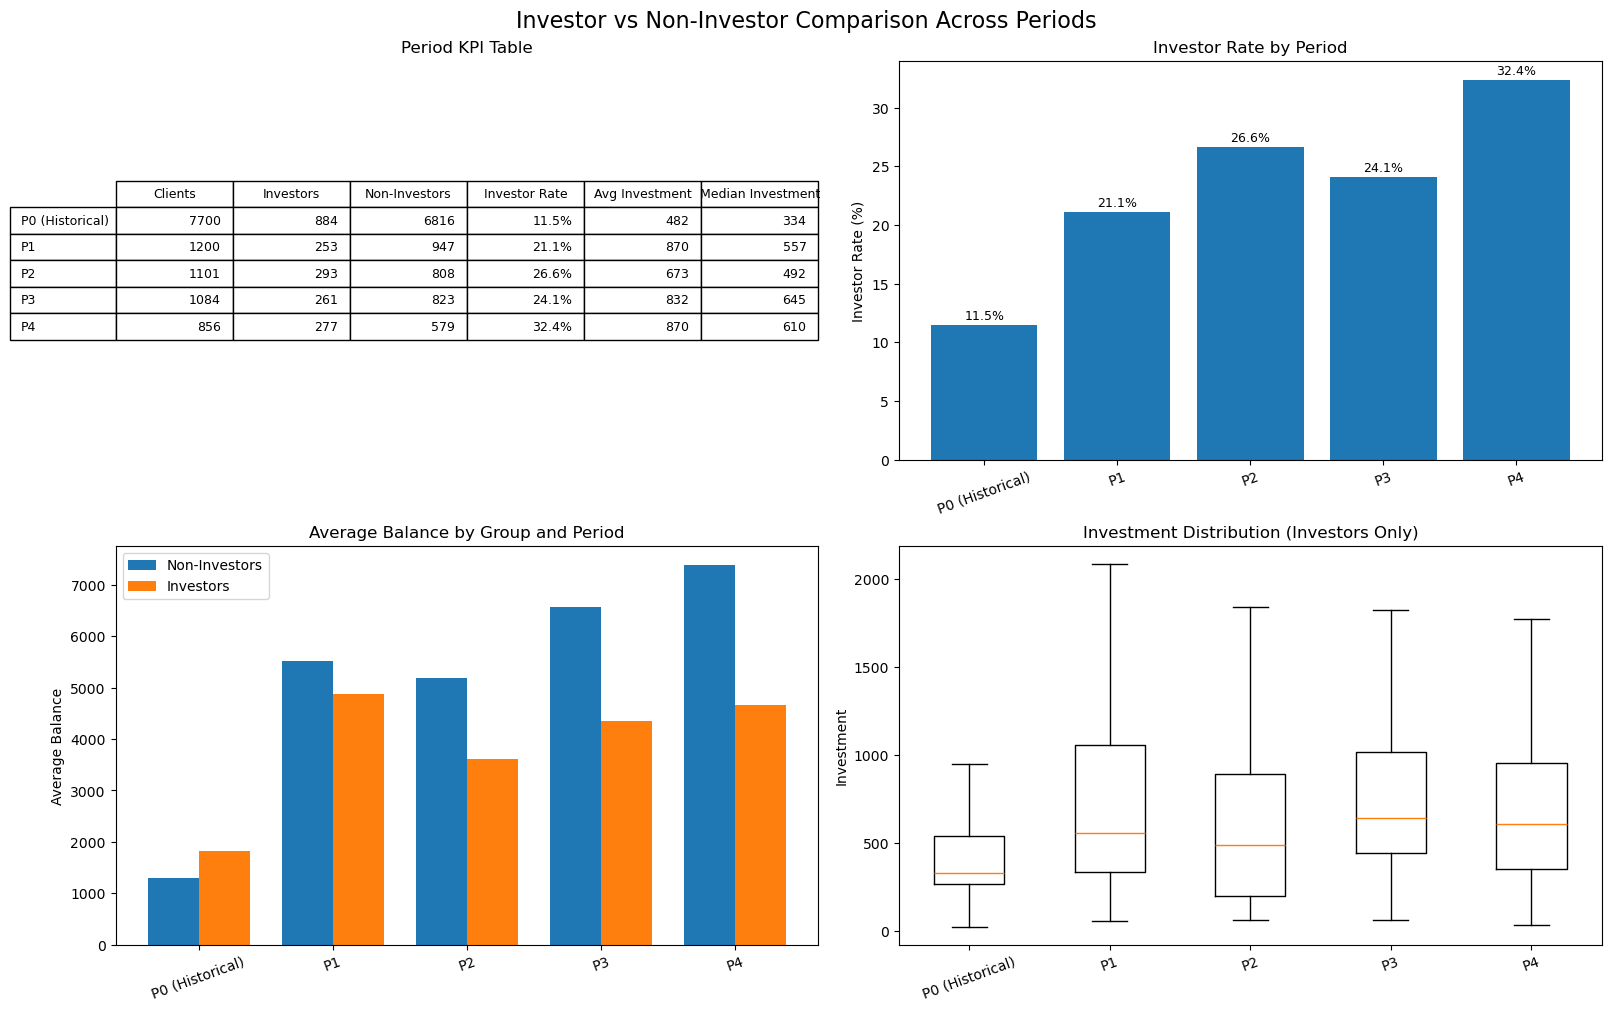

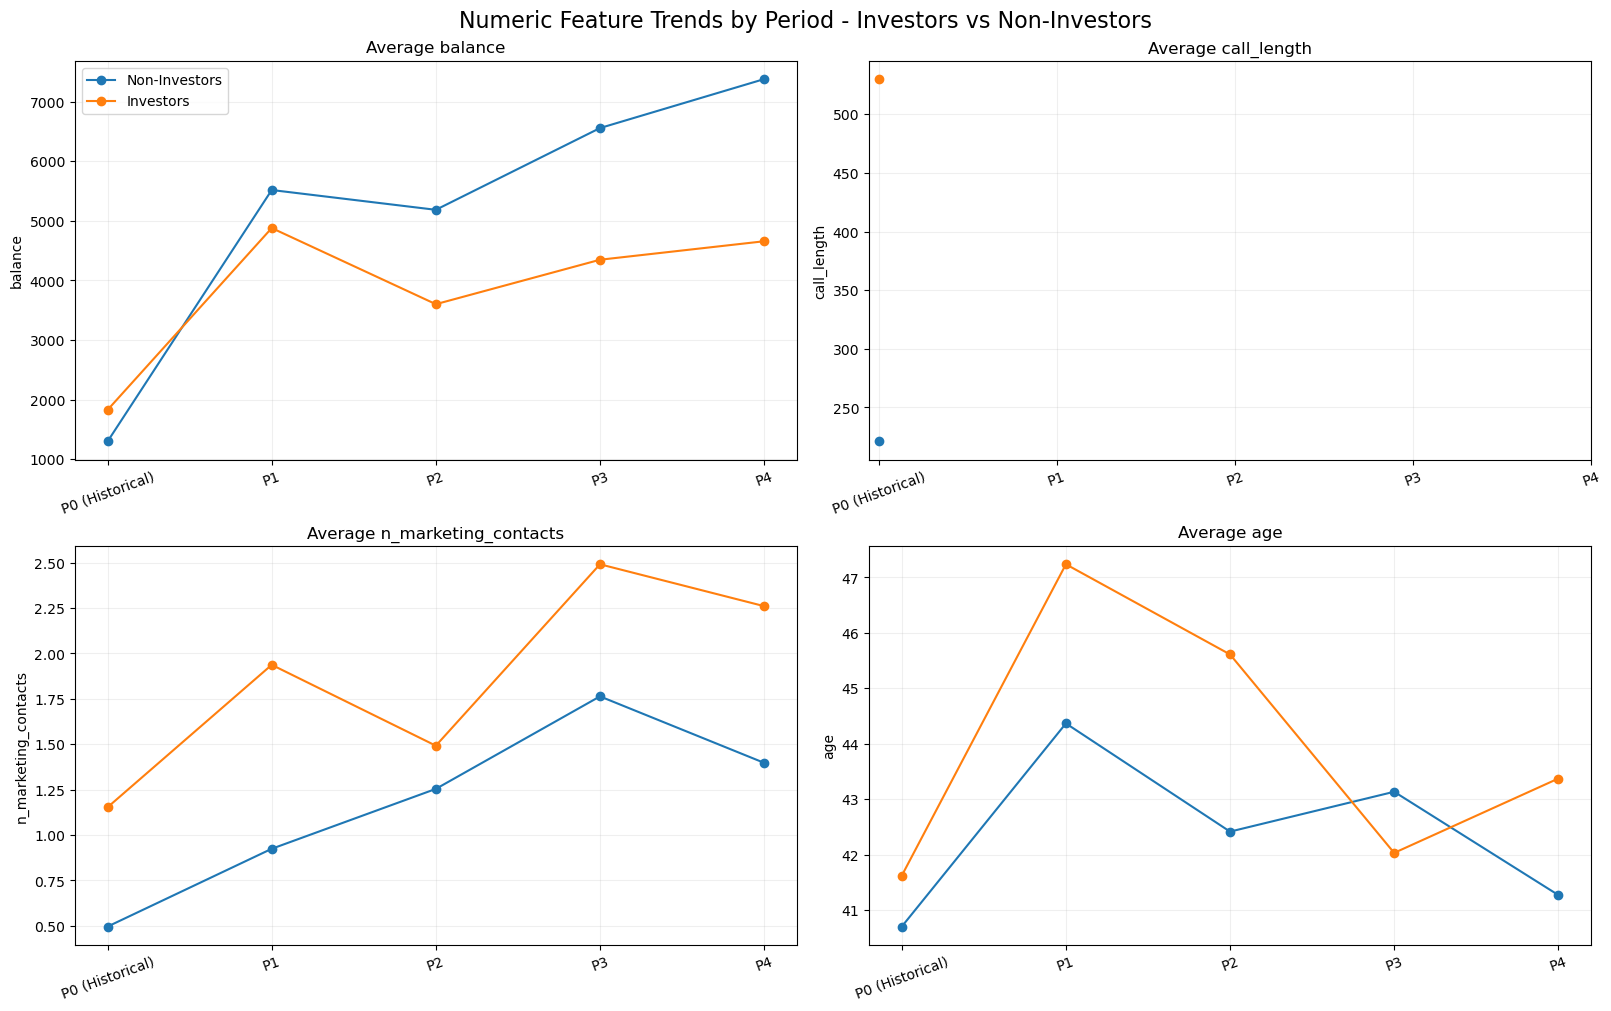

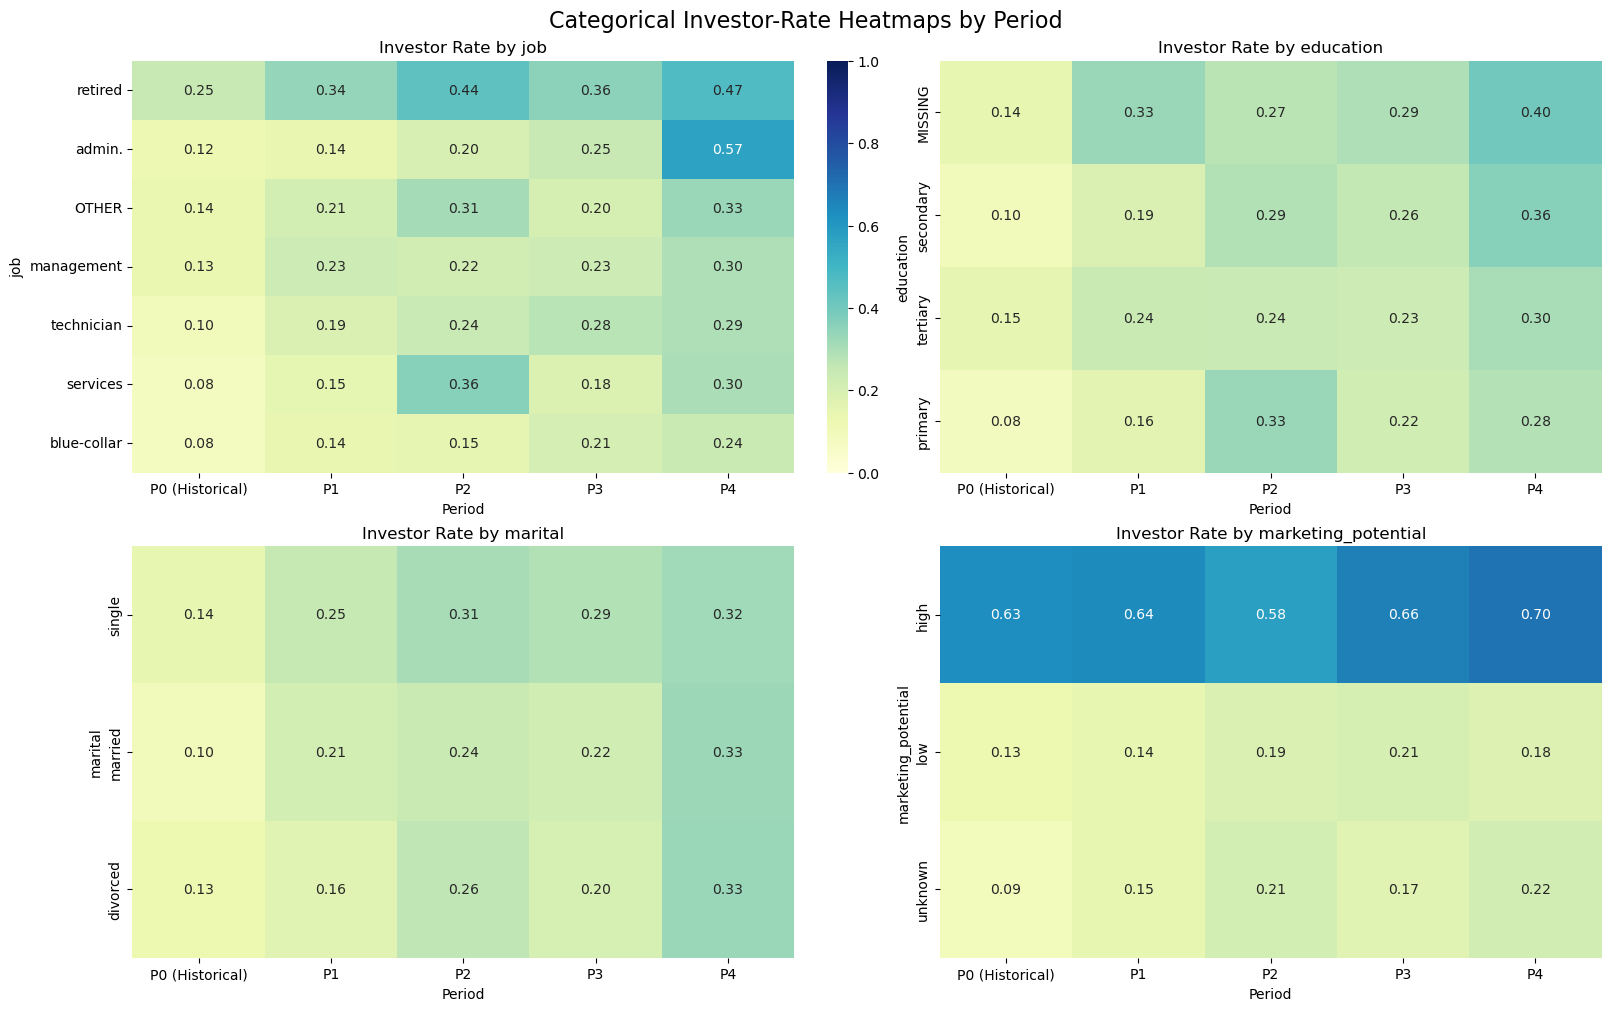

,Period Key,Period,Clients,Investors,Non-Investors,Investor Rate,Avg Investment (Investors),Median Investment (Investors),Total Investment (Investors),Avg Balance Investors,Avg Balance Non-Investors
0,0,P0 (Historical),7700,884,6816,0.114805,481.786968,333.91,425899.68,1828.033937,1298.634977
1,1,P1,1200,253,947,0.210833,869.854269,556.83,220073.13,4880.171581,5518.460190
2,2,P2,1101,293,808,0.266122,672.845188,492.31,197143.64,3602.213993,5186.194010
3,3,P3,1084,261,823,0.240775,831.581724,645.00,217042.83,4348.081609,6558.435334
4,4,P4,856,277,579,0.323598,870.249928,610.02,241059.23,4658.270361,7380.073264


In [130]:
weekly_investment_dashboard(df_all)['summary']


### Exploratory analysis interpretation

The exploratory analysis shows a clear structural shift from the historical baseline (P0) to the campaign periods (P1–P4). The investor rate increases steadily from 11.5% in P0 to 21.1% (P1), 26.6% (P2), slightly dips to 24.1% (P3), and reaches its peak at 32.4% in P4. This indicates a substantially higher conversion propensity during campaign periods, with P4 showing the strongest performance.

Investment levels among investors also increase compared to the historical baseline. Average investment rises from 482 (P0) to consistently higher levels across all campaign periods (e.g., 870 in P1 and P4), while medians follow a similar upward trend. This suggests that not only more clients invest, but they also invest larger amounts in later periods.


Balance remains a strong differentiator: non-investors consistently show higher average balances than investors across all periods, although both groups exhibit increasing trends over time. 
However, this pattern is likely influenced by selection bias in the campaign data. Compared to the historical baseline (P0), the campaign periods may target a different subset of clients, leading to a non-representative distribution of balance across investor groups. As a result, balance may appear inversely related to investment behavior, even though this relationship is driven by sampling effects rather than true underlying behavior.

Behavioral features show consistent patterns. Investors receive more marketing contacts in every period, with the gap widening in later periods (especially P3), supporting the importance of campaign intensity.

Demographically, investors tend to be slightly older on average, although this effect is not strictly monotonic across periods, suggesting that age plays a secondary role compared to behavioral features.

Categorical analysis confirms stable relative patterns: clients with high marketing potential consistently exhibit the highest investor rates (around 60–70%), while low and unknown segments remain significantly lower. This ranking persists across all periods, indicating robust segment-level behavior despite overall shifts in base rates. Similar stability is observed across job, education, and marital status categories.

Overall, the results indicate both a shift in base rates (more investors over time) and stable relative patterns across segments. This supports pooling data across periods for modeling, while explicitly accounting for temporal effects to capture changing baseline probabilities.

# 4. Classification Models

Classification is trained on a stratified 80/20 outer split and evaluated on holdout using ROC/PR metrics, threshold-based metrics, and calibration diagnostics. This stage provides the probability component used later in expected-profit ranking.

### 4.1 Distribution Check

We compare feature distributions between training data and Period 5 to detect major covariate shift before deployment. The outer split is then created for consistent downstream evaluation.

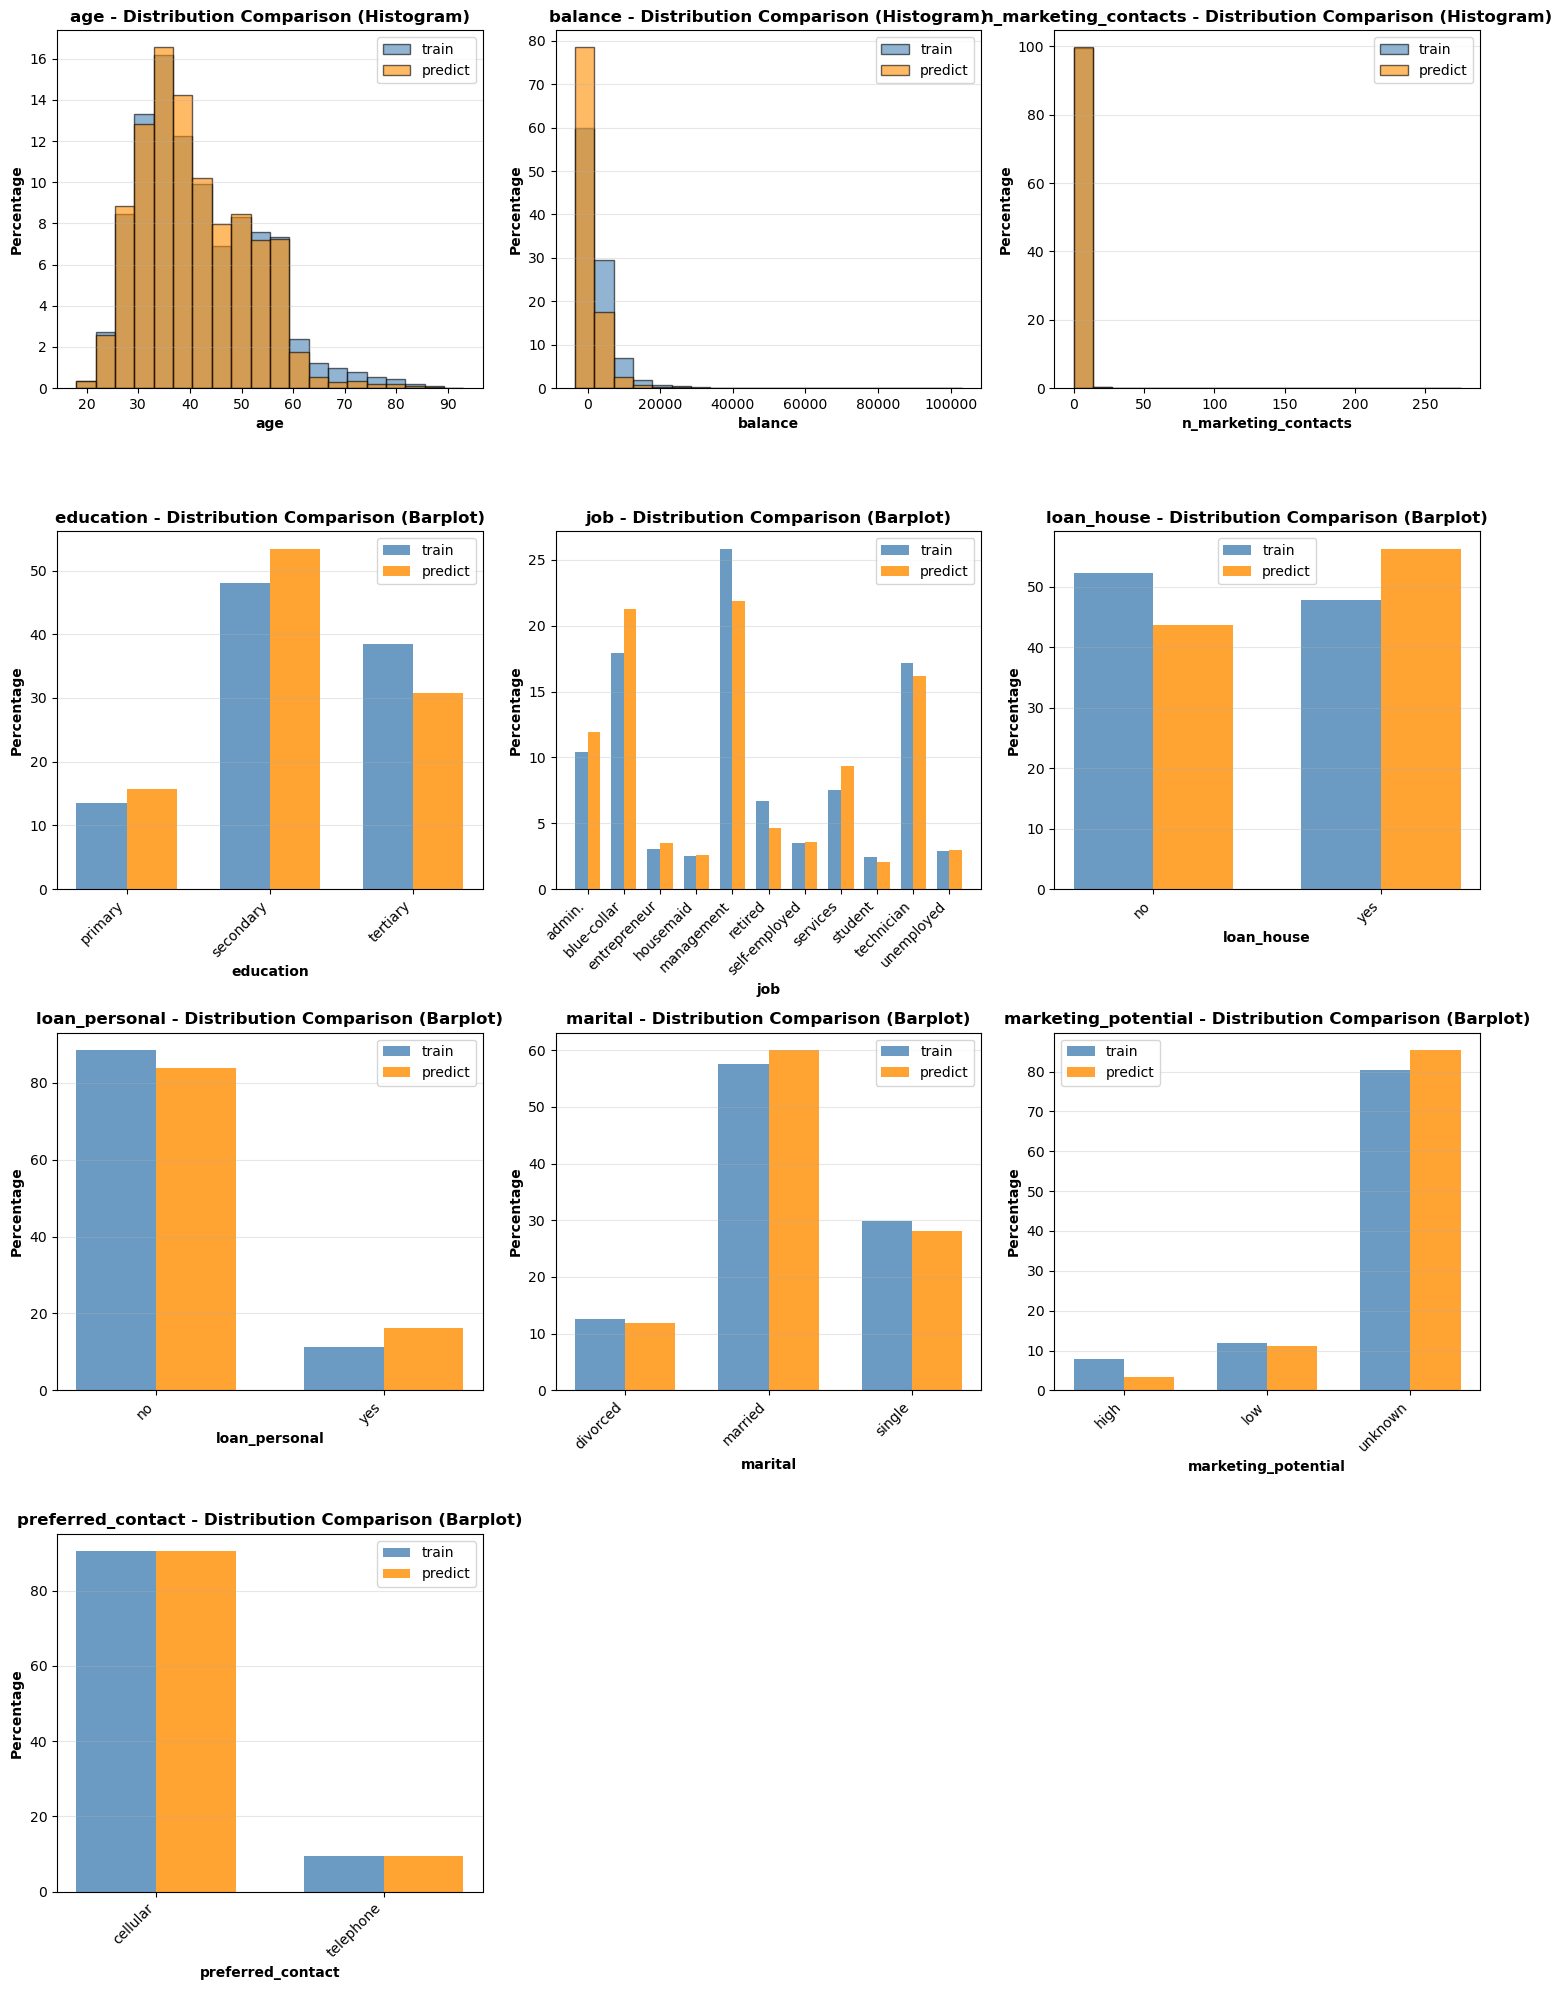


=== Distribution Comparison ===
          id  age            job   marital  education preferred_contact  \
0          1   31   entrepreneur    single   tertiary          cellular   
1          2   29     management   married   tertiary          cellular   
2          3   49    blue-collar  divorced  secondary          cellular   
3          4   23     management    single   tertiary          cellular   
4          5   42     technician   married  secondary               NaN   
...      ...  ...            ...       ...        ...               ...   
11936  38436   42     management   married   tertiary          cellular   
11937  38437   33  self-employed    single   tertiary          cellular   
11938  38438   61     management   married  secondary          cellular   
11939  38458   48         admin.   married  secondary          cellular   
11940  38485   26         admin.   married   tertiary          cellular   

        balance loan_house loan_personal  n_marketing_contacts  \


In [ ]:
compare_dist(df_all, df_data_predict)

#### Distribution check interpretation

The train-versus-Period-5 comparison suggests a **moderate covariate shift** rather than a severe distribution break. Core numeric variables (age, balance, and number of contacts) retain similar overall shapes, including strong right-skew in balance and contact counts. Differences in the upper tails of balance appear slightly reduced in Period 5 but remain broadly comparable.

For categorical variables, most shares remain relatively stable, but a few meaningful shifts are visible. In particular, the share of `high` marketing potential decreases while `unknown` increases noticeably, representing the most pronounced change. Additionally, there are moderate increases in loan-related categories (especially `loan_personal = yes`) and small shifts in job and marital distributions.

Overall, the observed differences may impact out-of-sample performance if unaccounted for, but they are not large enough to invalidate deployment. The results support training on pooled historical data, provided that robust validation, monitoring, and calibration checks are maintained to handle the observed drift.

### 4.2 Model Analysis and Selection

Additionally, the nearly identical target rates between train and test confirm the absence of label shift, indicating that observed differences are driven purely by covariate drift.

In [132]:
all_X_train, all_X_test, all_y_train, all_y_test = prepare_data(df_all, target_var="y")

Train dataset shape: (9552, 10), target shape: (9552,)
Test dataset shape: (2389, 10), target shape: (2389,)
Train positive rate: 0.1647822445561139
Test positive rate : 0.16492256174131437

Dropped columns: ['y', 'investment', 'call_length', 'period', 'week_id', 'timestamp', 'id']
Feature columns (first 10): ['age', 'job', 'marital', 'education', 'preferred_contact', 'balance', 'loan_house', 'loan_personal', 'n_marketing_contacts', 'marketing_potential'] 



#### Parameter Analysis
We conducted a parameter range analysis for each model in order to better and more objectively define them. 
We left it as a comment since it has only to be done once and then adjusted in the models dictionary above, but after it would just waste computational power.

In [133]:
# param_ranges = {"model__C": [0.1*i for i in range(1, 30)],
#                 "model__alpha": [0.5*i for i in range(21)],
#                 "model__l1_ratio": [0.1*i for i in range(11)],
#                 "model__max_depth": [i for i in range(1, 16)],
#                 "model__min_samples_leaf": [10*i for i in range(1, 31)],
#                 "model__n_estimators": [100*i for i in range(1, 6)],
#                 "model__n_neighbors": [10*i for i in range(1, 31)],
#                 "model__max_iter": [10*i for i in range(1, 31)],
#                 "model__learning_rate": [0.01*i for i in range(1, 11)],
#                 "model__max_features": [0.1*i for i in range(5, 11)],
#                 "model__subsample": [0.1*i for i in range(5, 11)], 
#                 "model__colsample_bytree": [0.1*i for i in range(5, 11)],
#                 "model__reg_lambda": [i for i in range(1, 21)]
#                 }

# param_analysis = {}
# for model_name, cfg in class_models.items():
#     pipeline = Pipeline([
#             ('preprocessor', cfg['preprocessor']),
#             ('variance', VarianceThreshold(threshold=1e-5)),
#             ('model', cfg['estimator'])
#         ])  
#     param_analysis[model_name] = {}
#     for param in cfg["param_grid"].keys():
#         if param in param_ranges.keys():
#             param_analysis[model_name][param] = find_parameter_range(pipeline, model_name, all_X_train, all_y_train, param_name=param, scoring="roc_auc", param_values=param_ranges[param])

The model benchmarking includes both linear and non-linear classifiers to capture different types of relationships in the data. Given the observed moderate covariate shift especially in variables such as `marketing_potential` linear models are expected to provide more stable generalization, while tree-based models may achieve higher in-sample performance but risk sensitivity to distributional changes.
Distance-based methods such as KNN are expected to perform less robustly under distribution shift due to their reliance on local neighborhoods.

In [134]:
all_class_results, all_class_models = analyse_models(class_models, df_all, target_var="y")

Train dataset shape: (9552, 10), target shape: (9552,)
Test dataset shape: (2389, 10), target shape: (2389,)
Train positive rate: 0.1647822445561139
Test positive rate : 0.16492256174131437

Dropped columns: ['y', 'investment', 'call_length', 'period', 'week_id', 'timestamp', 'id']
Feature columns (first 10): ['age', 'job', 'marital', 'education', 'preferred_contact', 'balance', 'loan_house', 'loan_personal', 'n_marketing_contacts', 'marketing_potential'] 

Running LogisticRegression_L2 ...
Running LogisticRegression_L1 ...
Running RidgeClassifier ...
Running LogisticRegression_ElasticNet ...
Running DecisionTree ...
Running RandomForest ...
Running KNN ...
Running HistGradientBoosting ...
Running XGBoost ...


The table shows the test performance of the different classification models. XGBoost achieves the best ROC-AUC (0.7793) and, together with HistGradientBoosting and RandomForest, also the highest PR-AUC. This indicates that tree-based ensemble models capture the overall ranking and structure in the data best.
In terms of precision, KNN is highest (0.6789), but it has a very low recall (0.1878). This means it predicts positives very conservatively but is often correct when it does. The logistic models and the RidgeClassifier show the opposite pattern: lower precision but much higher recall (around 0.64–0.65), meaning they identify more positive cases but with more false positives.
Looking at the F1-score, RidgeClassifier and LogisticRegression_L1 perform best, as they provide the most balanced trade-off between precision and recall. The tree-based models, while strong in AUC, have lower recall and therefore slightly lower F1 scores.
The Brier score is lowest for XGBoost, HistGradientBoosting, RandomForest, and DecisionTree, indicating better calibrated probability predictions. Overall, the boosting and random forest models provide the best overall performance, while the linear models offer a more balanced precision–recall trade-off.

In [135]:
summary_cols = [
    'model',
    'test_roc_auc',
    'test_pr_auc',
    'test_precision',
    'test_recall',
    'test_f1',
    'test_brier',
]

print(all_class_results[summary_cols].round(4).to_string(index=False))

                        model  test_roc_auc  test_pr_auc  test_precision  test_recall  test_f1  test_brier
                      XGBoost        0.7793       0.4486          0.6149       0.2513   0.3568      0.1136
         HistGradientBoosting        0.7775       0.4494          0.6125       0.2487   0.3538      0.1138
                 RandomForest        0.7771       0.4490          0.6387       0.2513   0.3607      0.1141
              RidgeClassifier        0.7725       0.4443          0.3480       0.6421   0.4514      0.2072
        LogisticRegression_L1        0.7712       0.4419          0.3307       0.6396   0.4360      0.1871
                 DecisionTree        0.7686       0.4250          0.5879       0.2716   0.3715      0.1147
        LogisticRegression_L2        0.7683       0.4363          0.3262       0.6548   0.4354      0.1884
                          KNN        0.7567       0.4175          0.6789       0.1878   0.2942      0.1169
LogisticRegression_ElasticNet        

### 4.3 Classification Results
HistGradientBoosting is one of the top-performing classifiers on the holdout set (ROC AUC 0.7775, PR AUC 0.4494), performing similarly to XGBoost and RandomForest and outperforming LogisticRegression_L2 (ROC AUC 0.7683). At a threshold of 0.5, it achieves precision 0.6125, recall 0.2487, and Brier score 0.1138, which is consistent with a ranking-focused campaign objective.

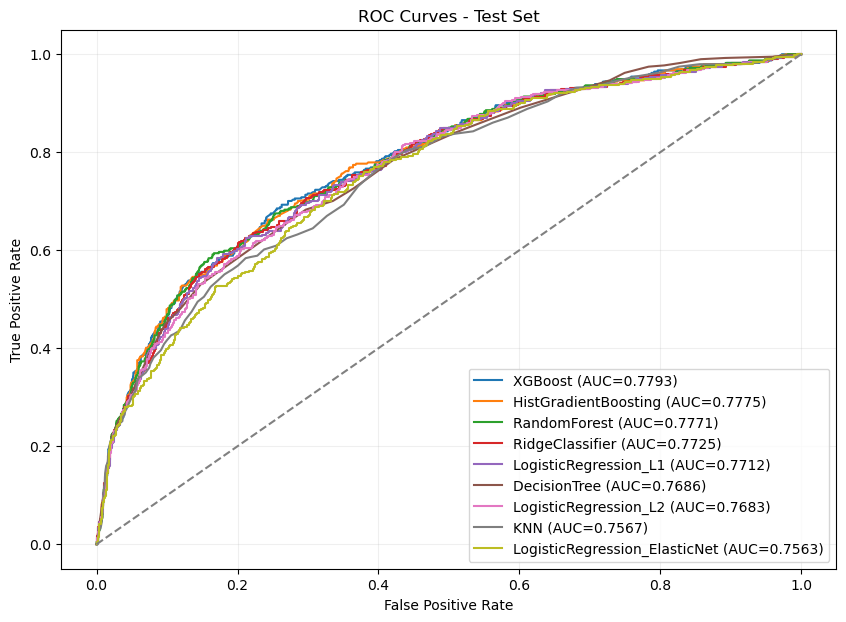

In [136]:
# ROC curves on holdout test set
plt.figure(figsize=(10, 7))

for _, row in all_class_results.iterrows():
    model_name = row['model']
    model = all_class_models[model_name]
    scores = positive_class_scores(model, all_X_test)
    fpr, tpr, _ = roc_curve(all_y_test, scores)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={row['test_roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curves - Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.show()

XGBoost is selected as the best uncalibrated classifier on the holdout set (ROC AUC 0.7793, PR AUC 0.4486). The cumulative gains and lift curves confirm strong ranking ability, with lift above 4 in the top segments and a consistent decline toward the baseline, indicating effective prioritization of high-probability targets for campaign use.

Selected best classifier uncalibrated: XGBoost


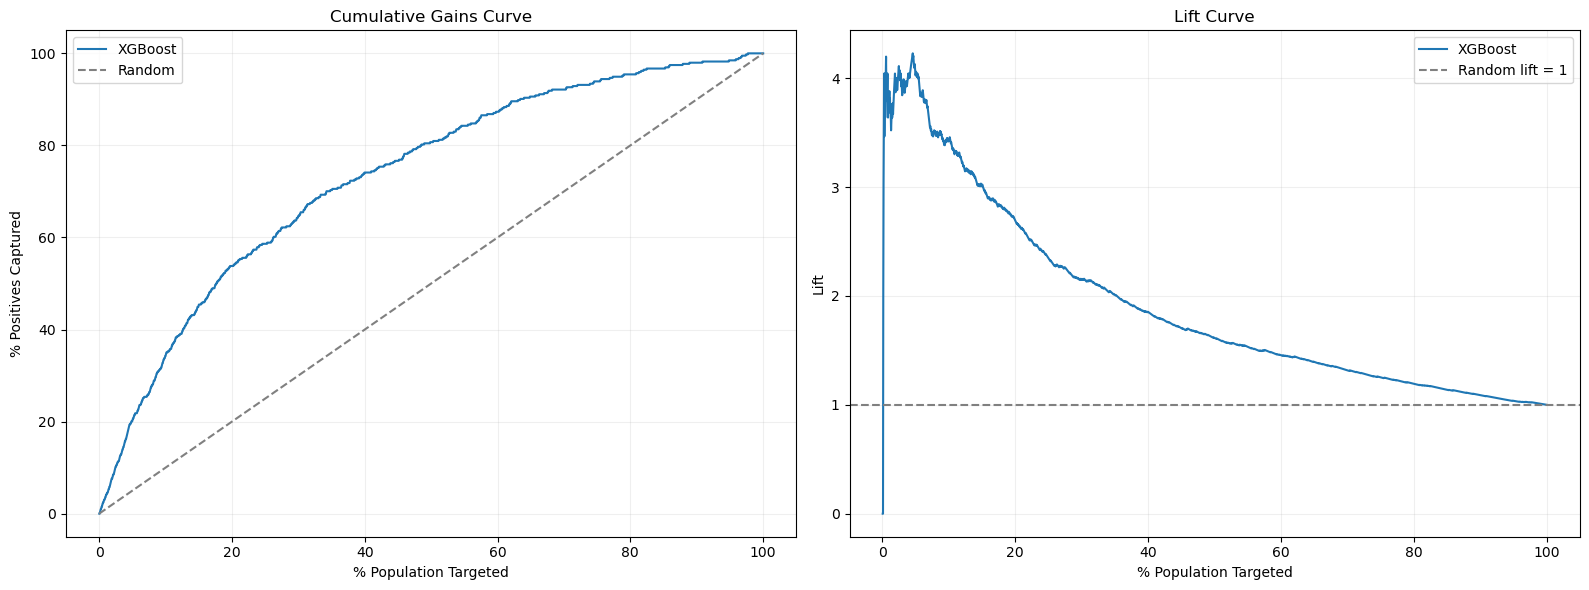

In [137]:
best_holdout_model_name = all_class_results.iloc[0]['model']
best_holdout_model = all_class_models[best_holdout_model_name]
print('Selected best classifier uncalibrated:', best_holdout_model_name)

plot_lift_and_cumulative({best_holdout_model_name: best_holdout_model}, all_X_test, all_y_test)

### 4.4 Ranking and Calibration Interpretation
At the top 20% of ranked clients, the model captures 50.89% of positives with 2.54x lift versus random, indicating strong prioritization performance. Calibration is acceptable in the low-to-mid probability range, with expected variability at the high-probability tail. We apply calibration to our model results to convert scores to probabilities, as we require accurate measures in this regard for our final expected profit calculations. We defined two ways of calibration (Platt & Isotonic) to be executed in parallel, saving the approach that produces the lower log-loss result, to capture model probabilities that fit real-world proportions of investors more accurately.

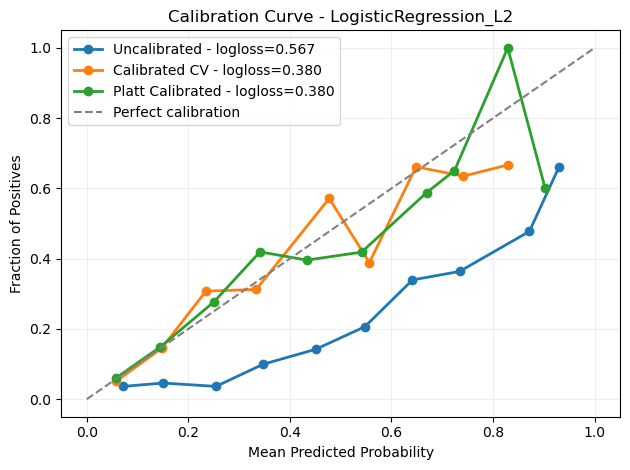

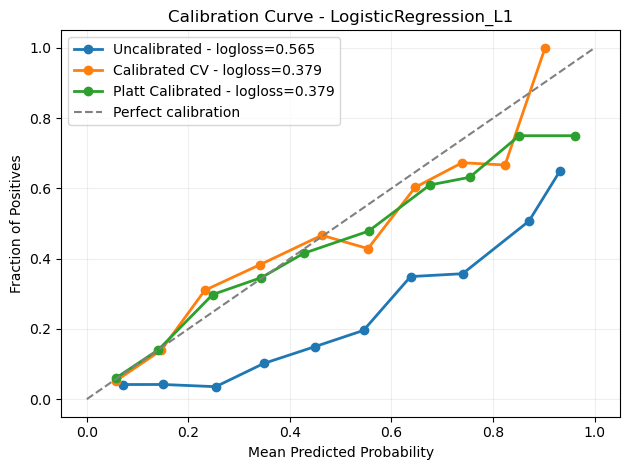

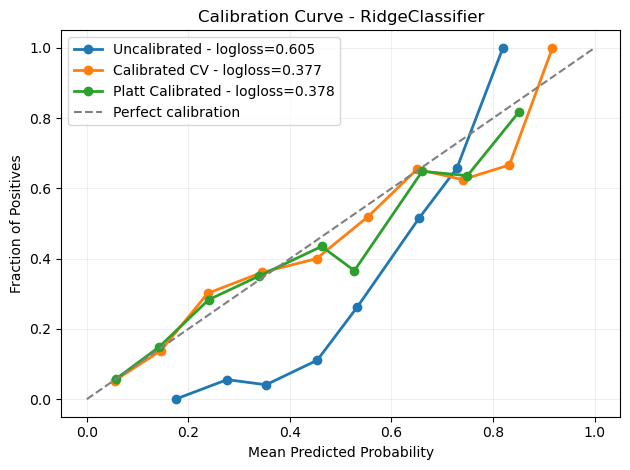

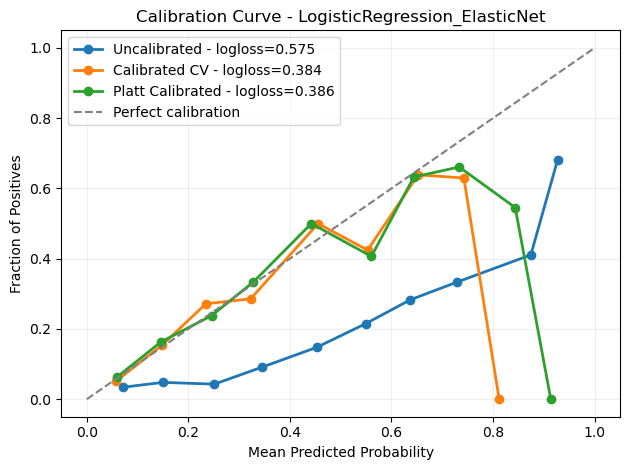

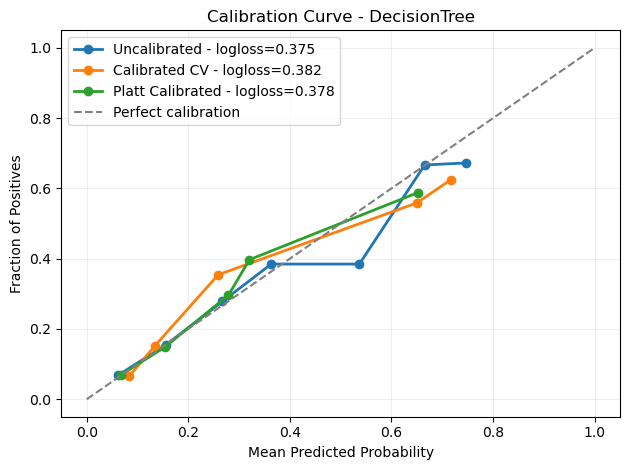

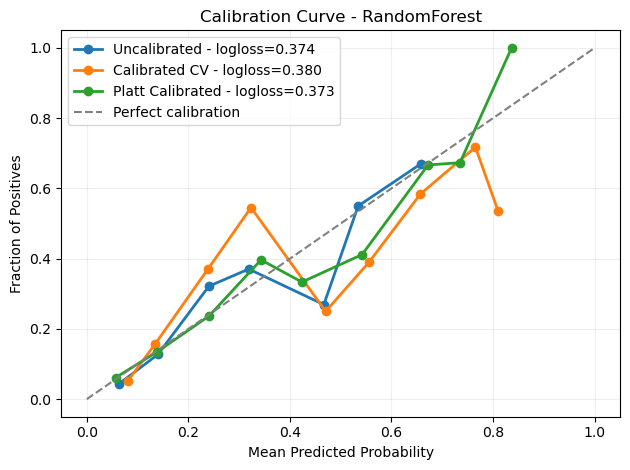

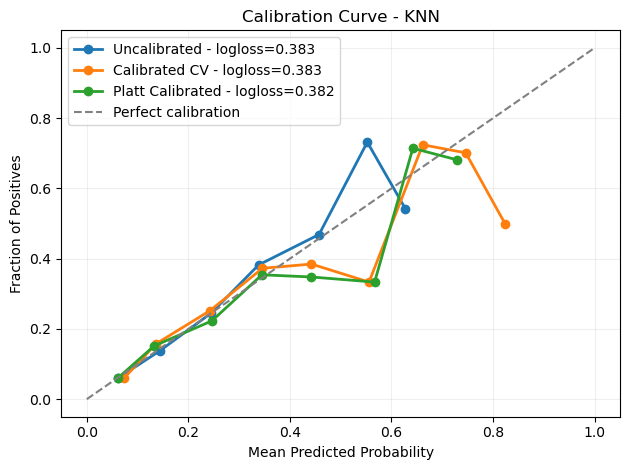

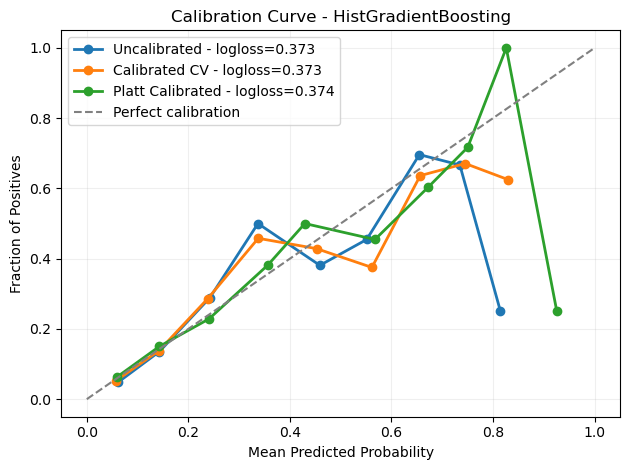

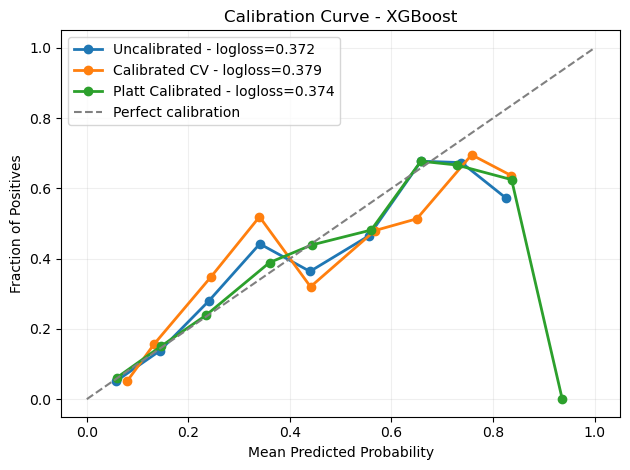

In [138]:
all_class_models_calibrated = calibrate(all_class_models, all_X_train, all_X_test, all_y_train, all_y_test)

In [139]:
metrics_results = []

for model_name, model in all_class_models_calibrated.items():
    probs_cal = positive_class_scores(model, all_X_test).clip(1e-15, 1 - 1e-15)
        
    logloss = log_loss(all_y_test, probs_cal)
    brier = brier_score_loss(all_y_test, probs_cal)
    
    metrics_results.append({
        'model': model_name,
        'log_loss': logloss,
        'brier_score': brier
    })

metrics_df = pd.DataFrame(metrics_results).sort_values(['log_loss', 'brier_score'])
print("Calibration Metrics Comparison (lower is better):")
print(metrics_df)

Calibration Metrics Comparison (lower is better):
                           model  log_loss  brier_score
7           HistGradientBoosting  0.372767     0.113836
5                   RandomForest  0.372778     0.113297
8                        XGBoost  0.373577     0.113732
2                RidgeClassifier  0.377127     0.114981
4                   DecisionTree  0.378081     0.115449
1          LogisticRegression_L1  0.378674     0.115602
0          LogisticRegression_L2  0.379968     0.116053
6                            KNN  0.382066     0.116480
3  LogisticRegression_ElasticNet  0.384496     0.117488


### Model performance interpretation (Lift & Cumulative Gains)

All models clearly outperform random selection, indicating strong predictive power in ranking investors. The cumulative gains curves show that a large proportion of positive cases can be captured by targeting only a relatively small share of the population.

In particular, the top 10–20% of the population already captures a disproportionately high share of investors, demonstrating strong early lift. This is further confirmed by lift values above 3–4 in the initial segments, meaning the models are several times more effective than random targeting.

Across models, performance differences are relatively small, suggesting that most algorithms learn similar patterns from the data. However, slight advantages can be observed for ensemble methods (e.g., Random Forest, Gradient Boosting, XGBoost), which tend to achieve marginally higher lift in the top-ranked segments.

As the targeted population increases, lift gradually converges towards 1, as expected, indicating diminishing returns when moving beyond the most promising clients.

Overall, the results indicate that the models are highly effective for ranking-based use cases such as targeted marketing or investment prediction. From a business perspective, focusing on the top-ranked segments (e.g., top 20–30%) would yield the highest return on campaign efforts.

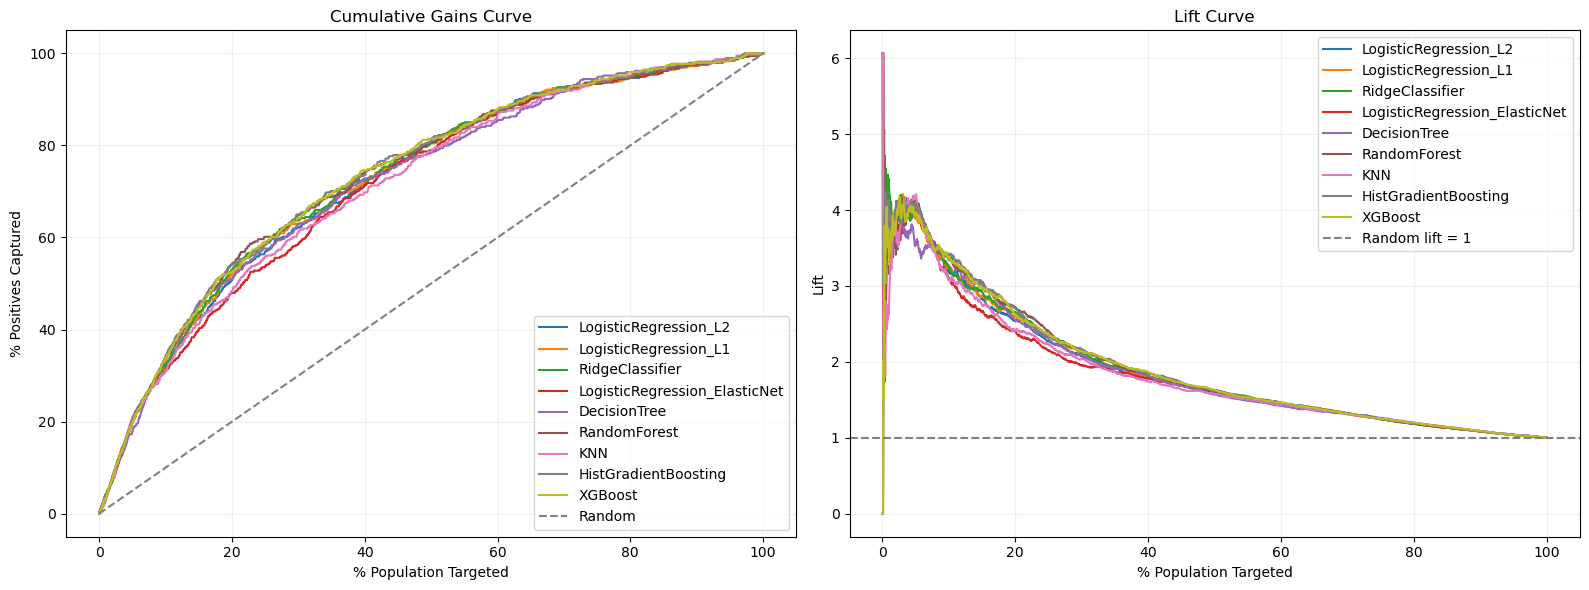

In [140]:
plot_lift_and_cumulative(all_class_models_calibrated, all_X_test, all_y_test)

The selected model (HistGradientBoosting) demonstrates strong ranking performance, clearly outperforming random selection. The cumulative gains curve shows that approximately 50% of all investors can be captured by targeting only the top ~20% of the population, indicating high targeting efficiency.

The lift curve further confirms this behavior, with peak lift values above 4 in the very top segments. This means that within the highest-ranked clients, the model is more than four times as effective as random selection. As expected, lift declines smoothly as more of the population is included, approaching 1 for the full population.

The distribution of predicted probabilities reveals a highly skewed pattern: most observations receive low predicted probabilities (below ~0.2), while a smaller subset is assigned significantly higher scores (up to ~0.8). This indicates strong class separation and enables effective ranking, but also suggests that the model is conservative in assigning high probabilities.

From a business perspective, the model is particularly well-suited for targeted interventions. Focusing on the top 10–30% of clients would capture a large share of potential investors while keeping outreach costs efficient. The clear separation in predicted probabilities also allows for flexible threshold selection depending on campaign objectives (e.g., precision vs. recall trade-off).

Selected best classifier uncalibrated: HistGradientBoosting


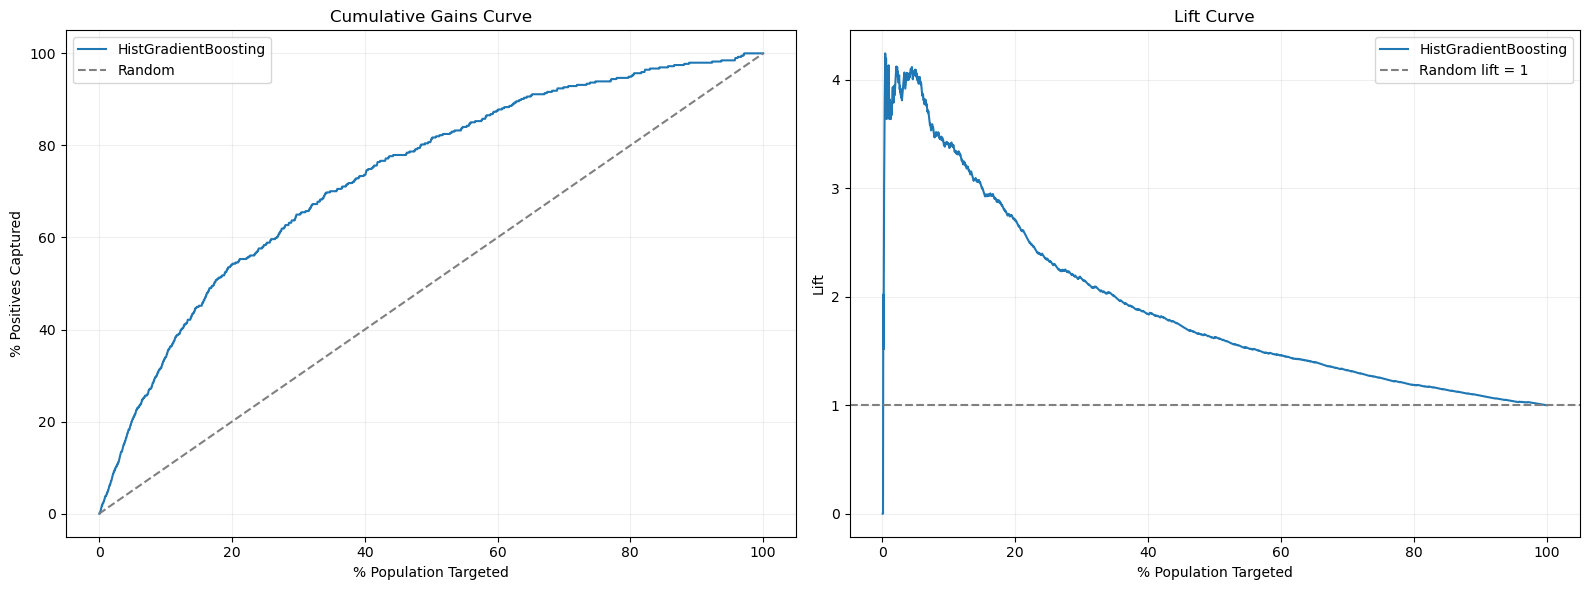

<function matplotlib.pyplot.show(close=None, block=None)>

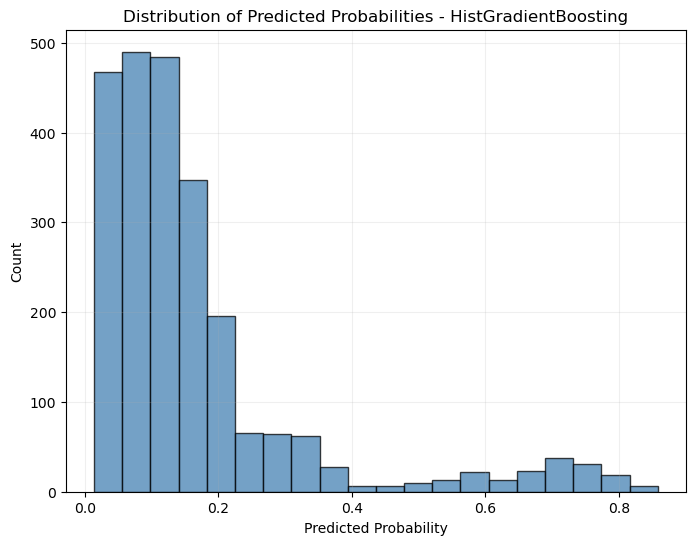

In [141]:
best_class_model_name = metrics_df.iloc[0]['model']
best_class_model = all_class_models_calibrated[best_class_model_name]
print('Selected best classifier uncalibrated:', best_class_model_name)

plot_lift_and_cumulative({best_class_model_name: best_class_model}, all_X_test, all_y_test)

# Probability distribution
probs_cal = positive_class_scores(best_class_model, all_X_test)

plt.figure(figsize=(8,6))
plt.hist(probs_cal, bins=20, edgecolor='black', alpha=0.75, color='steelblue')
plt.title(f'Distribution of Predicted Probabilities - {best_class_model_name}')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.show

### Threshold Analysis
For completeness purposes: We choose our previously proven approach of evaluating the optimal threshold of our chosen model by maximizing the F1 score. The results show, that the F1 score is maximized at a threshold value of 0.2215, balancing precision and recall of our model. This metric evaluation appears fitting, as in the given business case, we want to confidently capture a large number of investors while not taking the risk of trageting too many non-ivestors as a trade-off. The F1 score balances both of these requirements.

Since, in this use-case, we do not require a plain classification of investors and non-investors, we have no further use for the threshold value. Instead, we require the previously calibrated probabilities of investment, since they are part of our profit-maximization approach.

Threshold: inf
TN: 1995 | FP: 0 
FN: 394 | TP: 0

Threshold: 0.8580
TN: 1994 | FP: 1 
FN: 394 | TP: 0

Threshold: 0.8459
TN: 1993 | FP: 2 
FN: 394 | TP: 0

Threshold: 0.8400
TN: 1993 | FP: 2 
FN: 393 | TP: 1

Threshold: 0.8396
TN: 1992 | FP: 3 
FN: 393 | TP: 1

Threshold: 0.8181
TN: 1992 | FP: 3 
FN: 392 | TP: 2

Threshold: 0.8175
TN: 1992 | FP: 3 
FN: 391 | TP: 3

Threshold: 0.8133
TN: 1992 | FP: 3 
FN: 390 | TP: 4

Threshold: 0.8047
TN: 1992 | FP: 3 
FN: 389 | TP: 5

Threshold: 0.7992
TN: 1992 | FP: 3 
FN: 388 | TP: 6

Threshold: 0.7991
TN: 1992 | FP: 3 
FN: 387 | TP: 7

Threshold: 0.7980
TN: 1991 | FP: 4 
FN: 387 | TP: 7

Threshold: 0.7970
TN: 1991 | FP: 4 
FN: 386 | TP: 8

Threshold: 0.7960
TN: 1991 | FP: 4 
FN: 385 | TP: 9

Threshold: 0.7945
TN: 1990 | FP: 5 
FN: 385 | TP: 9

Threshold: 0.7944
TN: 1989 | FP: 6 
FN: 385 | TP: 9

Threshold: 0.7895
TN: 1989 | FP: 6 
FN: 384 | TP: 10

Threshold: 0.7866
TN: 1989 | FP: 6 
FN: 383 | TP: 11

Threshold: 0.7866
TN: 1988 | FP: 7 
FN: 383 | T

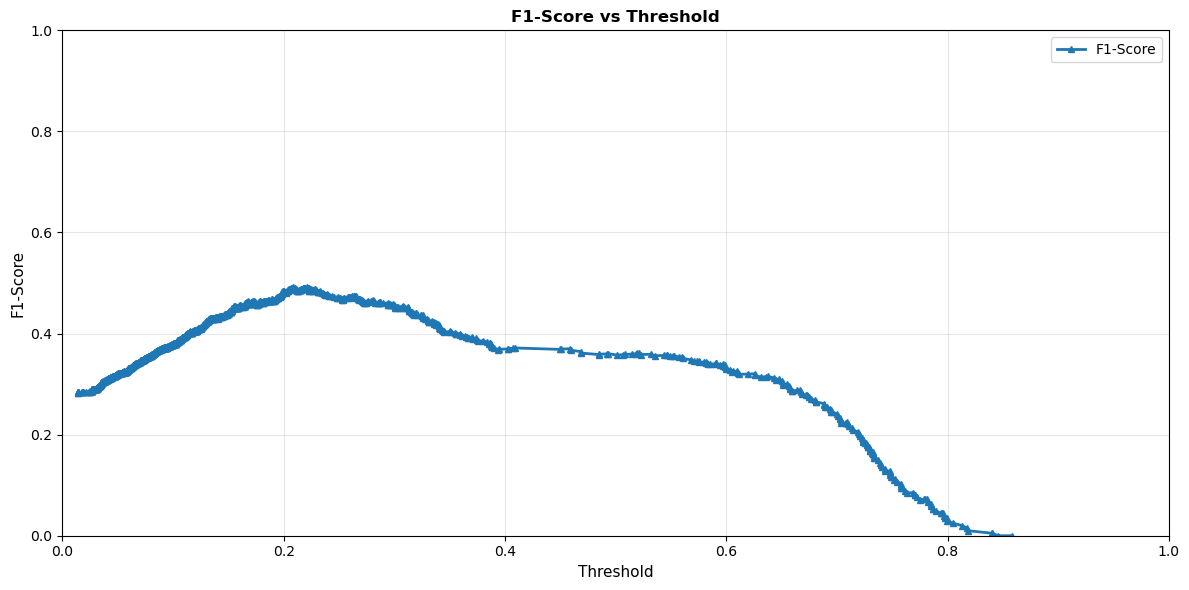

Best Threshold: 0.2215
TN: 1775 | FP: 220 
FN: 194 | TP: 200



In [142]:
best_threshold = find_best_threshold(all_X_test, all_y_test, best_class_model)

# 5. Regression Models

Regression estimates investment amount for investor clients (`y = 1`). To preserve end-to-end validity, regression is evaluated on the same outer split structure inherited from classification. This decision is made to ensure similar feature distribution in training/evaluation of both models and prevent data leakage. As both models eventually are combined to make a decision, splitting test/train data differently would result in information used for testing of either model to be known by the other in training and vice versa.

### 5.1 Aligned Investor-Only Split
Regression training and testing use only investor rows from the classification outer split. In this run, the split contains 1353 investor rows in train and 338 in test.

In [143]:
# Build regression split from the SAME outer split used in classification
outer_train_df = df_all.loc[all_X_train.index].copy()
outer_test_df = df_all.loc[all_X_test.index].copy()

reg_train_df = outer_train_df[outer_train_df['y'] == 1].copy()
reg_test_df = outer_test_df[outer_test_df['y'] == 1].copy()

drop_cols = ['y', 'investment', 'call_length', 'period', 'week_id', 'timestamp', 'id']
drop_cols = [c for c in drop_cols if c in df_all.columns]

inv_X_train = reg_train_df.drop(columns=drop_cols)
inv_X_test = reg_test_df.drop(columns=drop_cols)
inv_y_train = reg_train_df['investment']
inv_y_test = reg_test_df['investment']

print('Regression train shape:', inv_X_train.shape, 'target:', inv_y_train.shape)
print('Regression test shape :', inv_X_test.shape, 'target:', inv_y_test.shape)
print('Train investors from classifier outer train:', len(reg_train_df))
print('Test investors from classifier outer test :', len(reg_test_df))

Regression train shape: (1574, 10) target: (1574,)
Regression test shape : (394, 10) target: (394,)
Train investors from classifier outer train: 1574
Test investors from classifier outer test : 394


#### Parameter Analysis
We conducted a parameter range analysis for each model in order to better and more objectively define them. 
We left it as a comment since it has only to be done once and then adjusted in the models dictionary above, but after it would just waste computational power.

In [144]:
# param_ranges = {"model__regressor__alpha": [0.001*i for i in range(1,10)] + [0.01*i for i in range(1, 101)], #alpha test for Lasso and ElasticNet
#                 #"model__regressor__alpha": [i for i in range(1,51)], #alpha test for Ridge -> Note: only use one row of alpha at a time, have the other in comment
#                 "model__regressor__l1_ratio": [0.1*i for i in range(11)],
#                 "model__regressor__max_depth": [i for i in range(1, 21)],
#                 "model__regressor__min_samples_leaf": [5*i for i in range(1, 31)],
#                 "model__regressor__n_estimators": [100*i for i in range(1, 6)],
#                 "model__regressor__max_iter": [10*i for i in range(1, 31)],
#                 "model__regressor__learning_rate": [0.01*i for i in range(1, 11)],
#                 "model__regressor__max_features": [0.1*i for i in range(5, 11)],
#                 "model__regressor__subsample": [0.1*i for i in range(5, 11)], 
#                 "model__regressor__colsample_bytree": [0.1*i for i in range(5, 11)],
#                 "model__regressor__reg_lambda": [i for i in range(1, 21)]
#                 }

# param_analysis = {}
# for model_name, cfg in regression_models.items():
#     pipeline = Pipeline([
#             ('preprocessor', cfg['preprocessor']),
#             ('variance', VarianceThreshold(threshold=1e-5)),
#             ('model', cfg['estimator'])
#         ])  
#     param_analysis[model_name] = {}
#     for param in cfg["param_grid"].keys():
#         if param in param_ranges.keys():
#             param_analysis[model_name][param] = find_parameter_range(pipeline, model_name, inv_X_train, inv_y_train, param_name=param, scoring="neg_root_mean_squared_error", param_values=param_ranges[param])

This step models the conditional investment amount given that a client is an investor (y = 1). The regression task is trained exclusively on observed investor cases.

In [145]:
reg_results, reg_models = analyse_models(
    regression_models,
    df_all_investors,
    target_var='investment',
    classifier=False,
    fixed_split=(inv_X_train, inv_X_test, inv_y_train, inv_y_test),
)

Running LinearRegression ...
Running Ridge ...
Running Lasso ...
Running ElasticNet ...
Running DecisionTreeRegressor ...
Running RandomForestRegressor ...
Running HistGradientBoostingRegressor ...
Running XGBoostRegressor ...


The regression results show a clear performance hierarchy across models. Tree-based ensemble methods, particularly HistGradientBoosting and XGBoost, achieve the best performance, with the lowest RMSE (~127–174) and highest R² (~0.9478–0.97). This indicates strong predictive accuracy and the ability to capture non-linear relationships in investment amounts.

Random Forest and Decision Tree models perform moderately well but fall short of boosting methods, suggesting that while tree-based structures are suitable, ensemble boosting provides a significant advantage.

Linear models (Linear Regression, Ridge, Lasso, ElasticNet) perform substantially worse, with very high errors and even negative R² values in some cases. This indicates that linear assumptions are not appropriate for this problem and that the relationship between features and investment amount is highly non-linear.

Overall, the results suggest that investment amounts are driven by complex, non-linear patterns that are best captured by boosting-based models. From a modeling perspective, HistGradientBoosting emerges as the most reliable choice for predicting investment values.

In [146]:
summary_cols = [
    'model',
    'cv_best_score',
    'test_rmse',
    'test_mae',
    'test_medae',
    'test_r2'
]

print(reg_results[summary_cols].round(4).to_string(index=False))

                        model  cv_best_score  test_rmse  test_mae  test_medae  test_r2
HistGradientBoostingRegressor      -214.3111   127.9200   57.3460     22.8034   0.9719
             XGBoostRegressor      -216.5111   174.2583   68.4722     28.7356   0.9478
        RandomForestRegressor      -303.2134   214.5899   75.4450     24.6854   0.9208
        DecisionTreeRegressor      -343.1290   308.9378   99.6135     25.6998   0.8358
                   ElasticNet      -689.3081   704.2039  336.8697    181.1419   0.1470
                        Lasso      -691.9342   707.3844  338.3798    181.4503   0.1392
                        Ridge     -2934.6008  2236.4744  316.7587     90.5897  -7.6040
             LinearRegression     -2811.3706  2373.8839  329.0196     92.9132  -8.6938


Regression Results:

HistGradientBoostingRegressor achieves the best overall performance, with the lowest test RMSE (127.9200), the lowest MAE (57.3460), the lowest median absolute error (22.8034), and the highest R² (0.9719). XGBoostRegressor follows closely behind, also delivering strong predictive accuracy (RMSE 174.2583, R² 0.9478).

RandomForestRegressor and DecisionTreeRegressor perform reasonably well but remain clearly below the boosting-based models. In contrast, linear models (Linear Regression, Ridge, Lasso, ElasticNet) perform substantially worse, indicating that investment amounts are driven by strong non-linear relationships that cannot be captured adequately by linear assumptions.

Overall, the results identify HistGradientBoostingRegressor as the strongest standalone regression model for predicting investment amounts. Final model selection should additionally consider business objectives and end-to-end profitability in the combined classification-regression framework.

The permutation importance results highlight *marketing_potential* as the most influential feature, indicating that the model strongly relies on this variable to distinguish between investors and non-investors. This aligns with earlier findings, where high marketing potential segments consistently showed higher investor rates.

*preferred_contact* and *age* also contribute meaningfully to model performance, suggesting that both communication preferences and demographic factors play an important role in predicting investment behavior.

Financial variables such as *loan_house* and *balance* have moderate importance, indicating that while financial status matters, it is not the primary driver of investment decisions in this dataset.

Categorical features like *marital*, *education*, and *job* show relatively low importance, implying that these variables provide limited additional predictive value beyond the stronger behavioral and segmentation features.

Interestingly, *n_marketing_contacts* has near-zero or slightly negative importance, suggesting that its marginal contribution is limited once other features (such as marketing potential) are already included in the model.

Overall, the results indicate that behavioral and targeting-related features dominate the prediction task, while purely demographic variables play a secondary role.

In [147]:
perm = permutation_importance(
    best_class_model,
    all_X_test,
    all_y_test,
    n_repeats=10,
    random_state=1,
    scoring='roc_auc',
    n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': all_X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

imp_df.head(20)

,feature,importance_mean,importance_std
9,marketing_potential,0.067277,0.003984
4,preferred_contact,0.040665,0.003852
0,age,0.035623,0.003159
6,loan_house,0.017156,0.005893
5,balance,0.016500,0.005601
7,loan_personal,0.006811,0.002646
2,marital,0.004619,0.001390
3,education,0.000724,0.000368
1,job,-0.000101,0.000232
8,n_marketing_contacts,-0.000324,0.001043


In [148]:
best_reg_model_name = reg_results.iloc[0]['model']
best_reg_model = reg_models[best_reg_model_name]
print('Selected best regressor:', best_reg_model_name)

Selected best regressor: HistGradientBoostingRegressor


### Selected Standalone Regressor
The selected standalone regressor is HistGradientBoostRegressor (lowest holdout RMSE: 127.92).

The predicted vs. true plot shows a strong alignment along the diagonal, indicating that the model captures the overall relationship between features and investment amounts well. Most observations lie close to the 45-degree line, confirming high predictive accuracy, especially for low to medium investment values.

Overall, the model performs very well for the majority of cases but is less precise for high-value investments. From a business perspective, this implies reliable predictions for typical clients, while large investments may require additional modeling attention or specialized treatment.

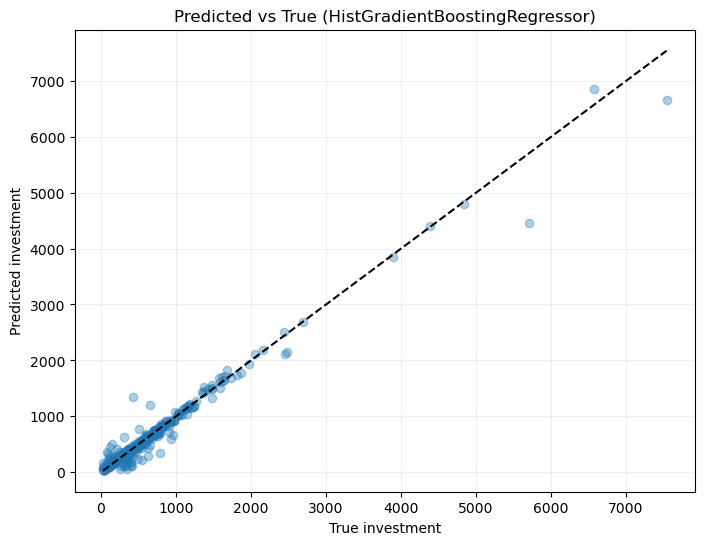

In [149]:
best_y_pred = np.clip(best_reg_model.predict(inv_X_test), a_min=0, a_max=None)

plt.figure(figsize=(8, 6))
plt.scatter(inv_y_test, best_y_pred, alpha=0.35)
line_min = min(float(inv_y_test.min()), float(best_y_pred.min()))
line_max = max(float(inv_y_test.max()), float(best_y_pred.max()))
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--', color='black')
plt.xlabel('True investment')
plt.ylabel('Predicted investment')
plt.title(f'Predicted vs True ({best_reg_model_name})')
plt.grid(alpha=0.2)
plt.show()

The residual plot shows that errors are generally centered around zero, indicating that the model is overall well-calibrated and does not exhibit strong global bias.
However, a clear pattern emerges: the variance of residuals increases with higher predicted investment values, suggesting heteroscedasticity. This indicates that the model becomes less precise for larger investment amounts, with both under- and over-predictions becoming more pronounced.
Additionally, several large residuals (outliers) are visible at higher prediction levels, reinforcing the observation that extreme investment values are harder to predict accurately. This is consistent with the earlier predicted-vs-true plot.

For lower and medium investment ranges, residuals are tightly clustered, confirming strong predictive performance in the majority of cases.
Overall, the model performs well for typical investment levels but exhibits increasing uncertainty and variability for high-value predictions. This suggests that additional modeling strategies (e.g., transformation of the target variable or separate modeling of high-value segments) could further improve performance.

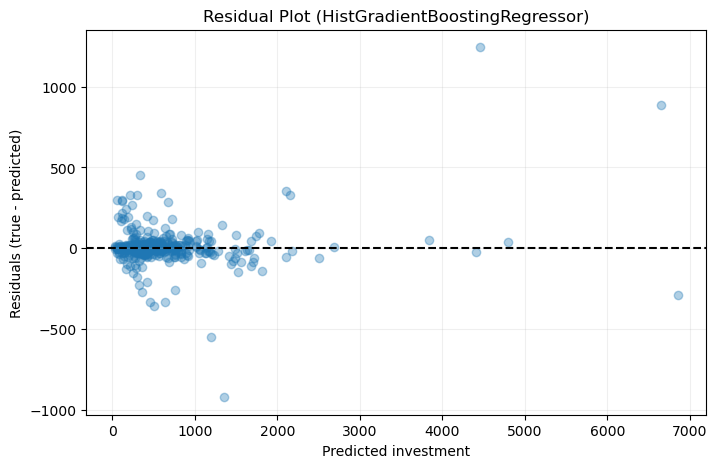

In [150]:
# Additional residual diagnostic (complements predicted-vs-true plot)
residuals = inv_y_test - best_y_pred

plt.figure(figsize=(8, 5))
plt.scatter(best_y_pred, residuals, alpha=0.35)
plt.axhline(0, linestyle='--', color='black')
plt.xlabel('Predicted investment')
plt.ylabel('Residuals (true - predicted)')
plt.title(f'Residual Plot ({best_reg_model_name})')
plt.grid(alpha=0.2)
plt.show()

# 6. Business Selection and Final Deployment

All classifier-regressor pairs are evaluated on aligned holdout data using realized profit under the 1,200-contact constraint. The best pair is then refit on full training data and applied to Period 5.

### Pairwise Business Evaluation
This step evaluates all combinations of calibrated classification models and regression models on the aligned holdout set from a business perspective.

For each classifier–regressor pair, the classifier estimates the probability of purchase, while the regressor predicts the potential investment amount. These two outputs are combined into an expected profit score that accounts for commission revenue and contact cost.

Clients are then ranked by expected profit, and the cumulative expected profit curve is used to determine the profit-maximizing number of contacts under the campaign capacity constraint.

Finally, all model combinations are compared based on realized and expected holdout profit, allowing selection of the classifier–regressor pair that performs best in terms of business value rather than only predictive accuracy.

### Selected Business Pair (This Run)
This visualization compares all classifier–regressor combinations based on realized holdout profit.
Each bar represents the business outcome of one model pair after ranking clients by expected profit and selecting the profit-maximizing number of contacts under the campaign capacity constraint. The best-performing combination is highlighted to show which end-to-end setup delivers the highest realized business value.
This comparison makes it possible to evaluate models not only by predictive accuracy, but by their actual contribution to campaign profitability.

Selected best business pair:
Classifier: RandomForest
Regressor: HistGradientBoostingRegressor
Holdout selected clients: 729
Holdout realized profit: 4676.55
Holdout expected profit: 4733.73


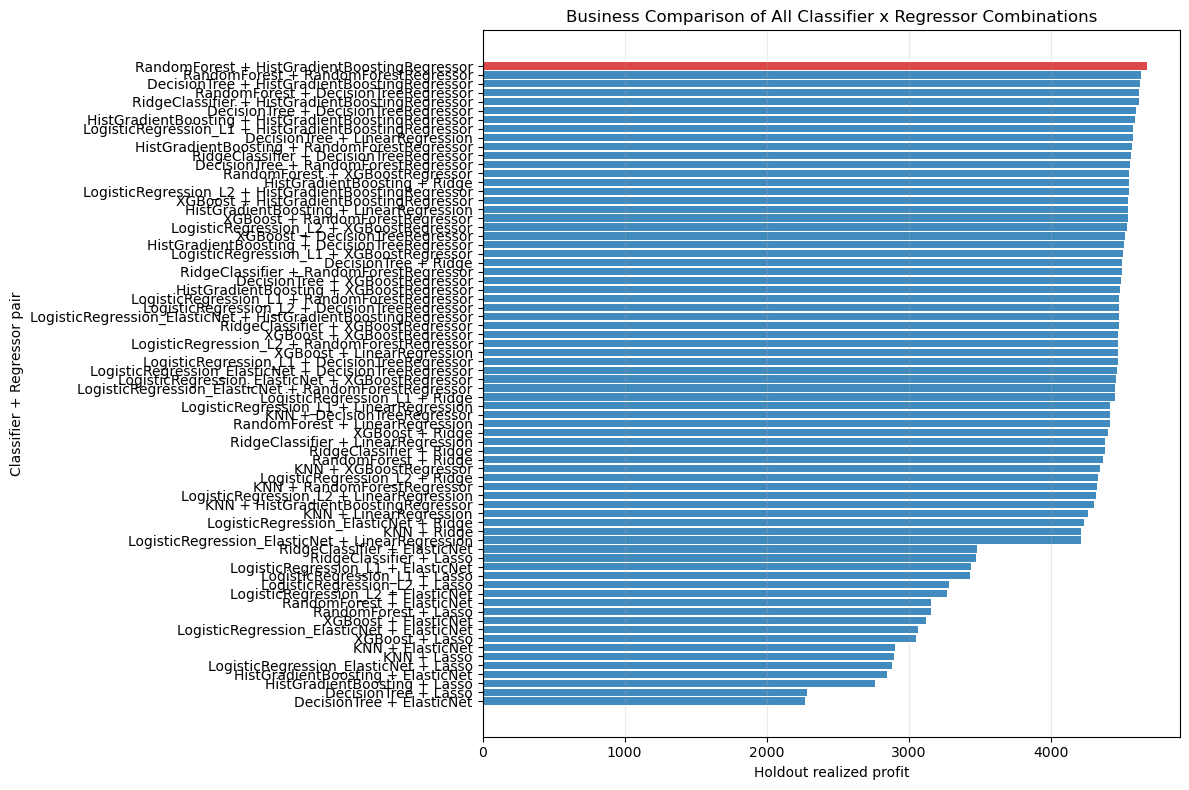

In [152]:
business_best_classifier_name, business_best_regressor_name = business_approach(df_all, all_class_models_calibrated, reg_models, all_X_test)

### Calibration Analysis
We check the calibration results again, comparing log-loss for both uncalibrated and calibrated versions of our chosen classifier. As we achieve lower log-loss and hence more accurate probabilities with calibration, we supports our decision to calibrate the scores.

In [153]:
scores_uncalibrated = positive_class_scores(all_class_models[business_best_classifier_name], all_X_test)
probs_calibrated = positive_class_scores(all_class_models_calibrated[business_best_classifier_name], all_X_test)

logloss_uncal = log_loss(all_y_test, scores_uncalibrated)
logloss_cal = log_loss(all_y_test, probs_calibrated)

print(f"LogLoss Uncalibrated Model: {logloss_uncal:.4f}")
print(f"LogLoss Calibrated Model: {logloss_cal:.4f}")

LogLoss Uncalibrated Model: 0.3745
LogLoss Calibrated Model: 0.3728


In [ ]:
# Saving the identified best models for later use
business_best_classifier_model = all_class_models_calibrated[business_best_classifier_name]
business_best_regressor_model = reg_models[business_best_regressor_name]

print('Classifier used for Pillar 3:', business_best_classifier_name)
print('Regressor used for Pillar 3:', business_best_regressor_name)

Classifier used for Pillar 3: RandomForest
Regressor used for Pillar 3: HistGradientBoostingRegressor


### Back Testing Analysis
In this section, we sequentially apply backtesting of our selected model combination on data from the previous periods. The goal is to determine whether performance remains consistent over time.

We can observe, that while the expected profit varries and appears to be slightly overconfidently predicted by our model combination, the conversion rate of targets to actual investors remains consistently around 27%-32%. In terms of investor identification, we therefor seem to perform consistently well, even though overall profit predictions appear to be overconfident in the beginning, but approach the actual realized profit closer as of period 3. Comparing our model performance to our performance in the prior weeks, we would've consistently outscored our previous models. Since we also only have access to the results data of each week, it is hard to assess whether our model can be accurately assessed this way, since the fraction of data in the first 2 periods is quite small.

In [ ]:
backtest_results = backtesting(df_all, prediction_datasets, business_best_classifier_model, business_best_regressor_model)

In [172]:
print(backtest_results)

   period  n_pred_targets  pred_target_profit  n_actual_targets  \
0       1           710.0         6591.776288               198   
1       2           791.0         6021.903851               214   
2       3           873.0         5576.416380               238   
3       4           835.0         6842.420142               272   

   actual_target_profit  
0            5389.31795  
1            4053.73640  
2            4762.48410  
3            6506.63425  


### Sensitivity Analysis
To test the robustness of our model to data fluctuations, we perform a sensitivity test to analyze the effect on the match-rate of our model pipeline. The resulst show, that up to a introduction of random noise of 5%, our models maintain a 90% match-rate, meaning that they are able to identify targets reasonably consistent despite data-fluctuations. Since this is the case, we see no cause for making adjustments moving forward with our selected models. Only of deviations would become sufficiently large, around 10%, the match-rate would decrease to 83%. 


Noise sensitivity summary:
   sigma  #_targets  target_profit  match_rate
0   0.00    734.000    5188.580674    1.000000
1   0.01    734.511    5200.304926    0.977691
2   0.05    736.236    5438.786185    0.900000
3   0.10    741.129    5999.333440    0.827113


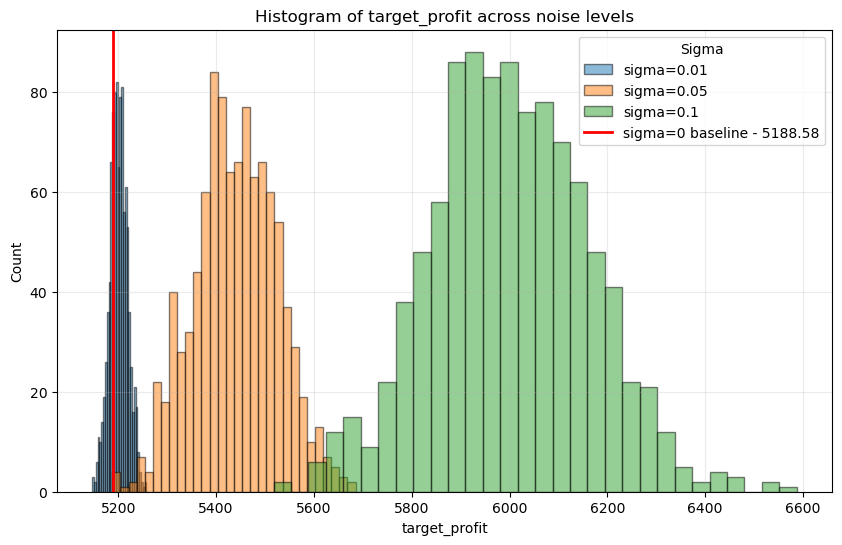

In [ ]:
sensitivity_results = noise_sensitivity(all_X_test, business_best_classifier_model, business_best_regressor_model)

### Period 5 Targeting Outcome

The selected business pair is refit on all available training data before scoring Period 5 leads.

The final scoring covers 7700 leads and selects 790 targets. Here, constrained and unconstrained optima coincide (N* = 790), so the 1,200-contact limit is not binding.

Prediction leads: 6711
Selected targets (<=1200): 824
Optimal constrained N for prediction: 824


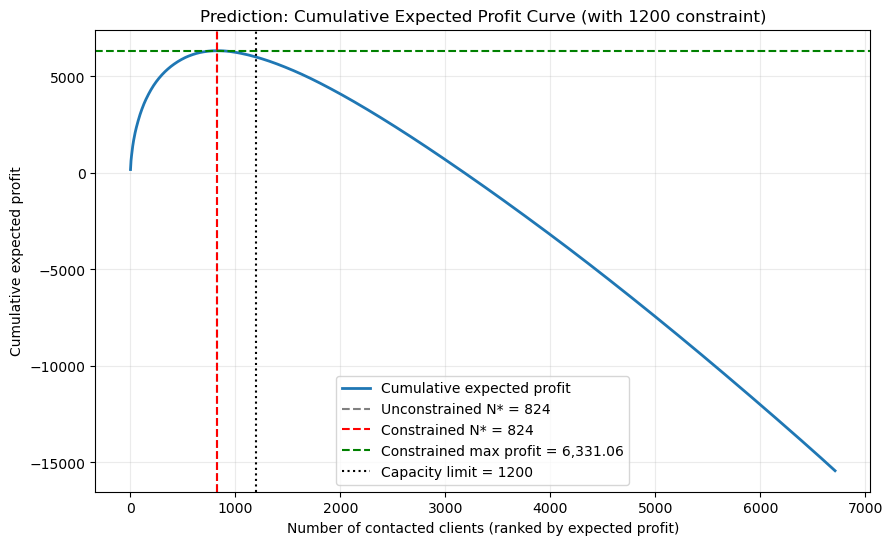

Prediction unconstrained N*: 824
Prediction constrained N* (<=1200): 824


In [176]:
excluded_cols = ['id', 'y', 'investment', 'week_id', 'period']
feature_cols = [c for c in df_all.columns if c not in excluded_cols]

pred_scored = predict_final_set(df_data_predict, business_best_classifier_model, business_best_regressor_model, excluded_cols, feature_cols)

pred_scored[['id', 'target']].to_csv("Targets_WK_Final.csv", index=False)

pred_scored[['id', 'target', 'probability_of_purchase', 'predicted_investment', 'expected_profit']].to_csv("campaign_file.csv", index=False)

# Period_5 Results Analysis

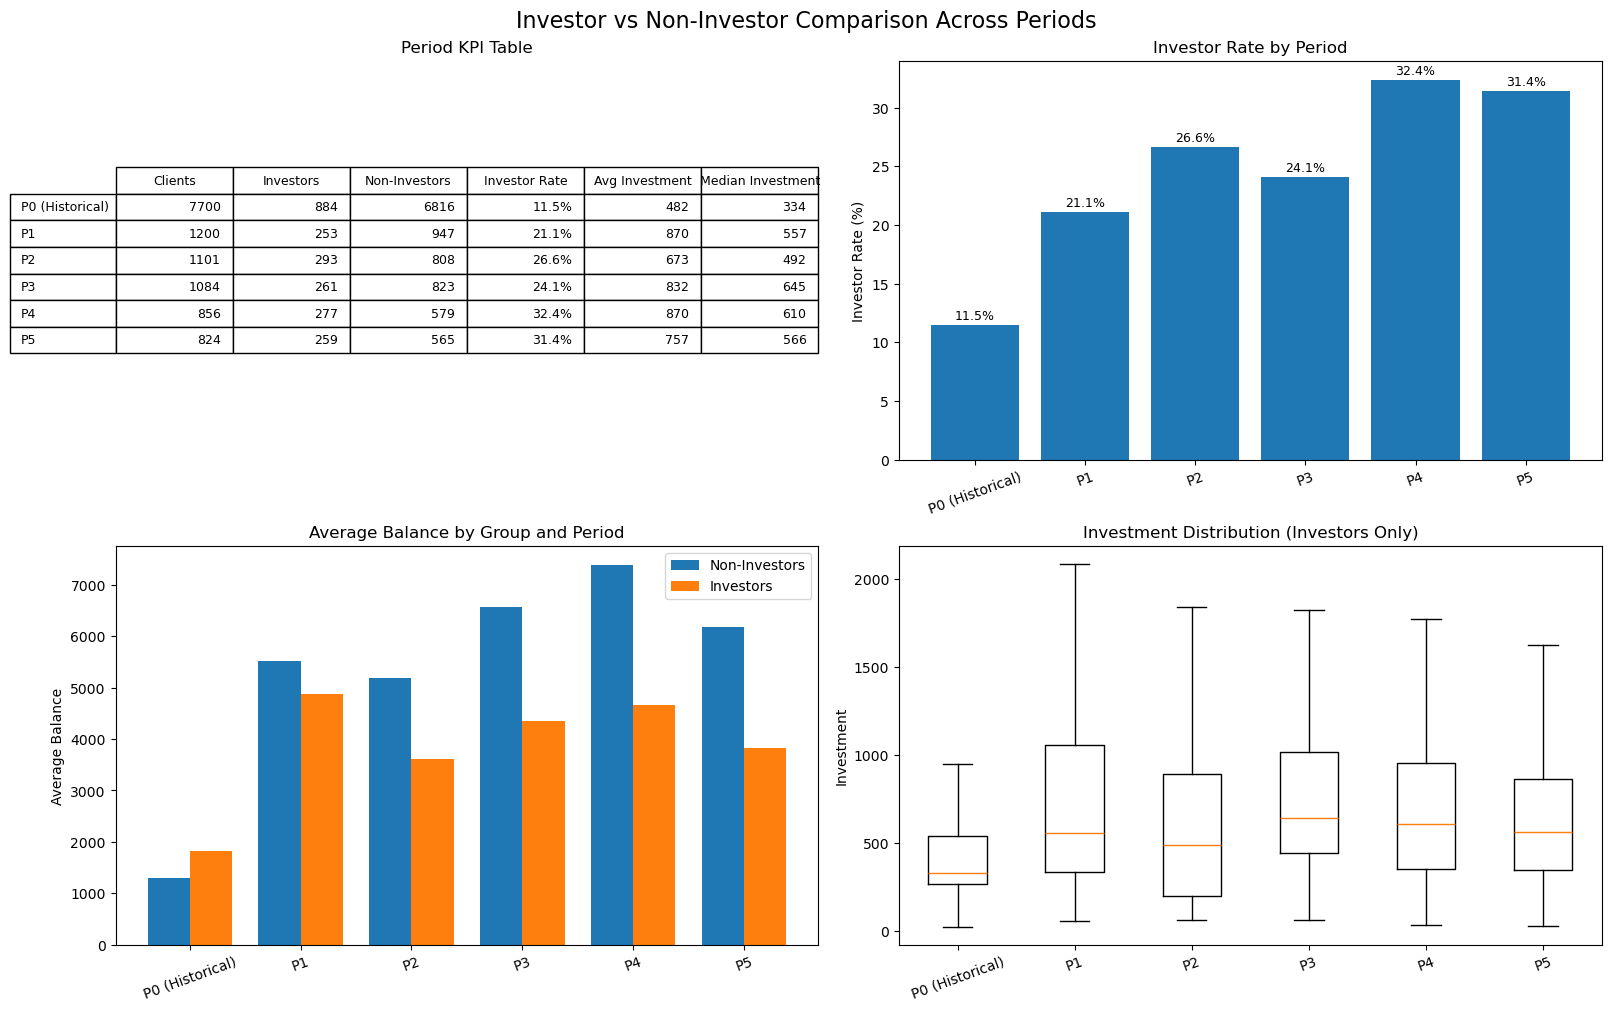

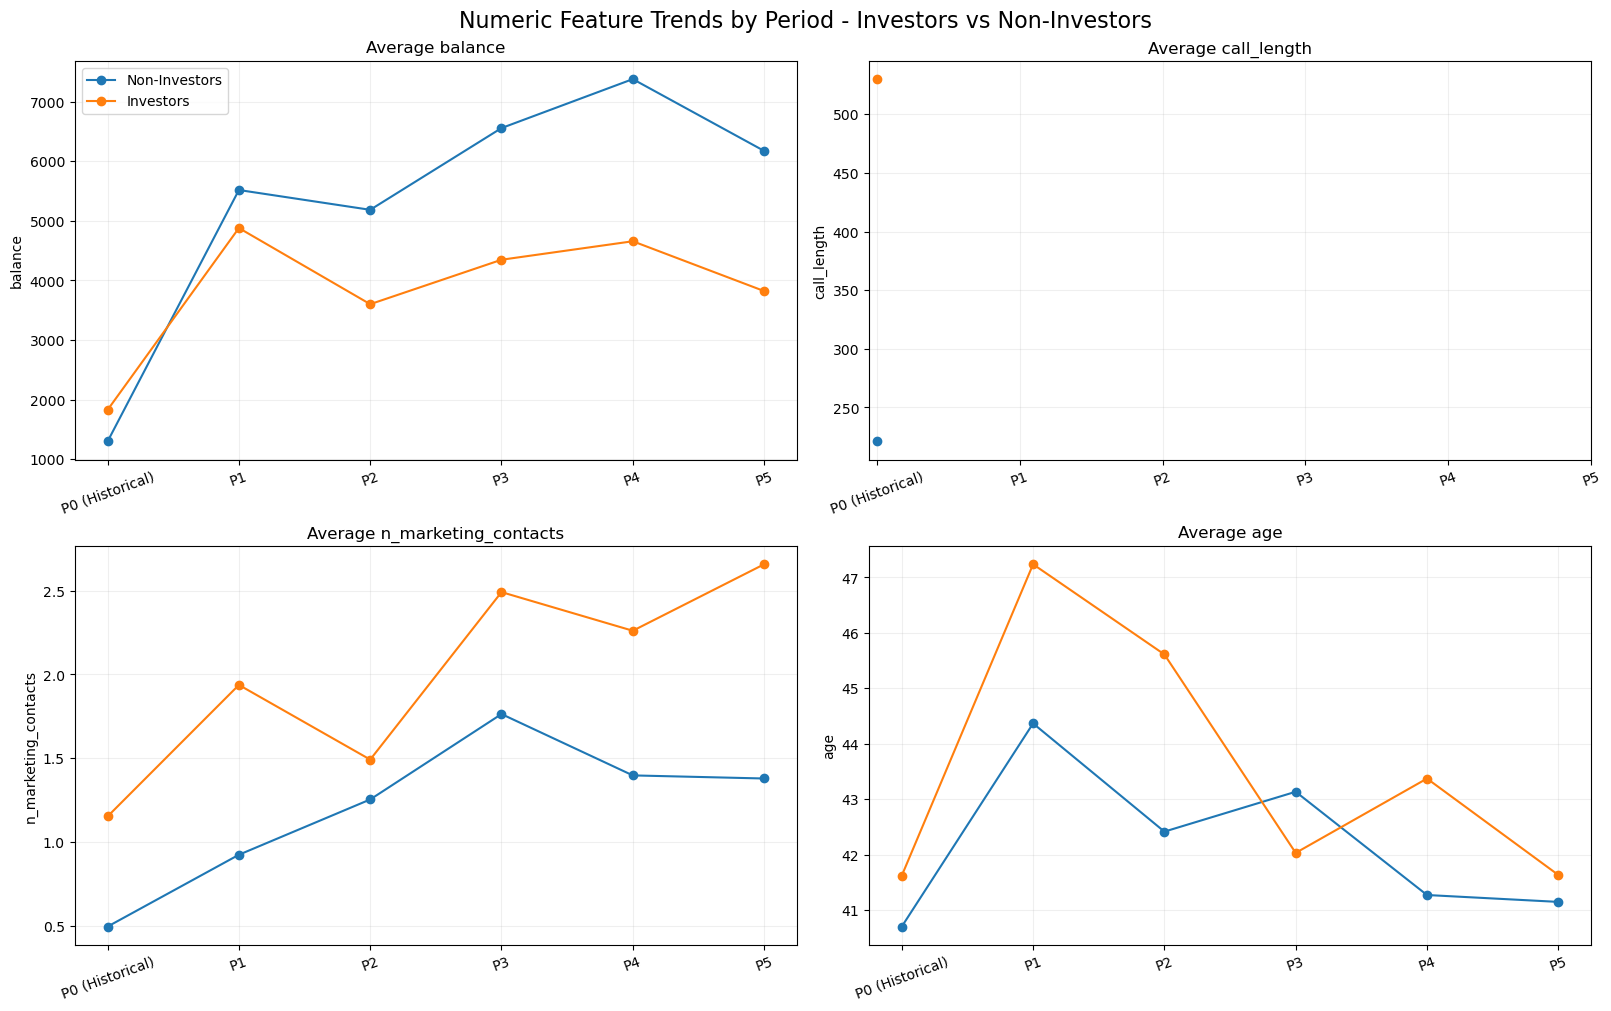

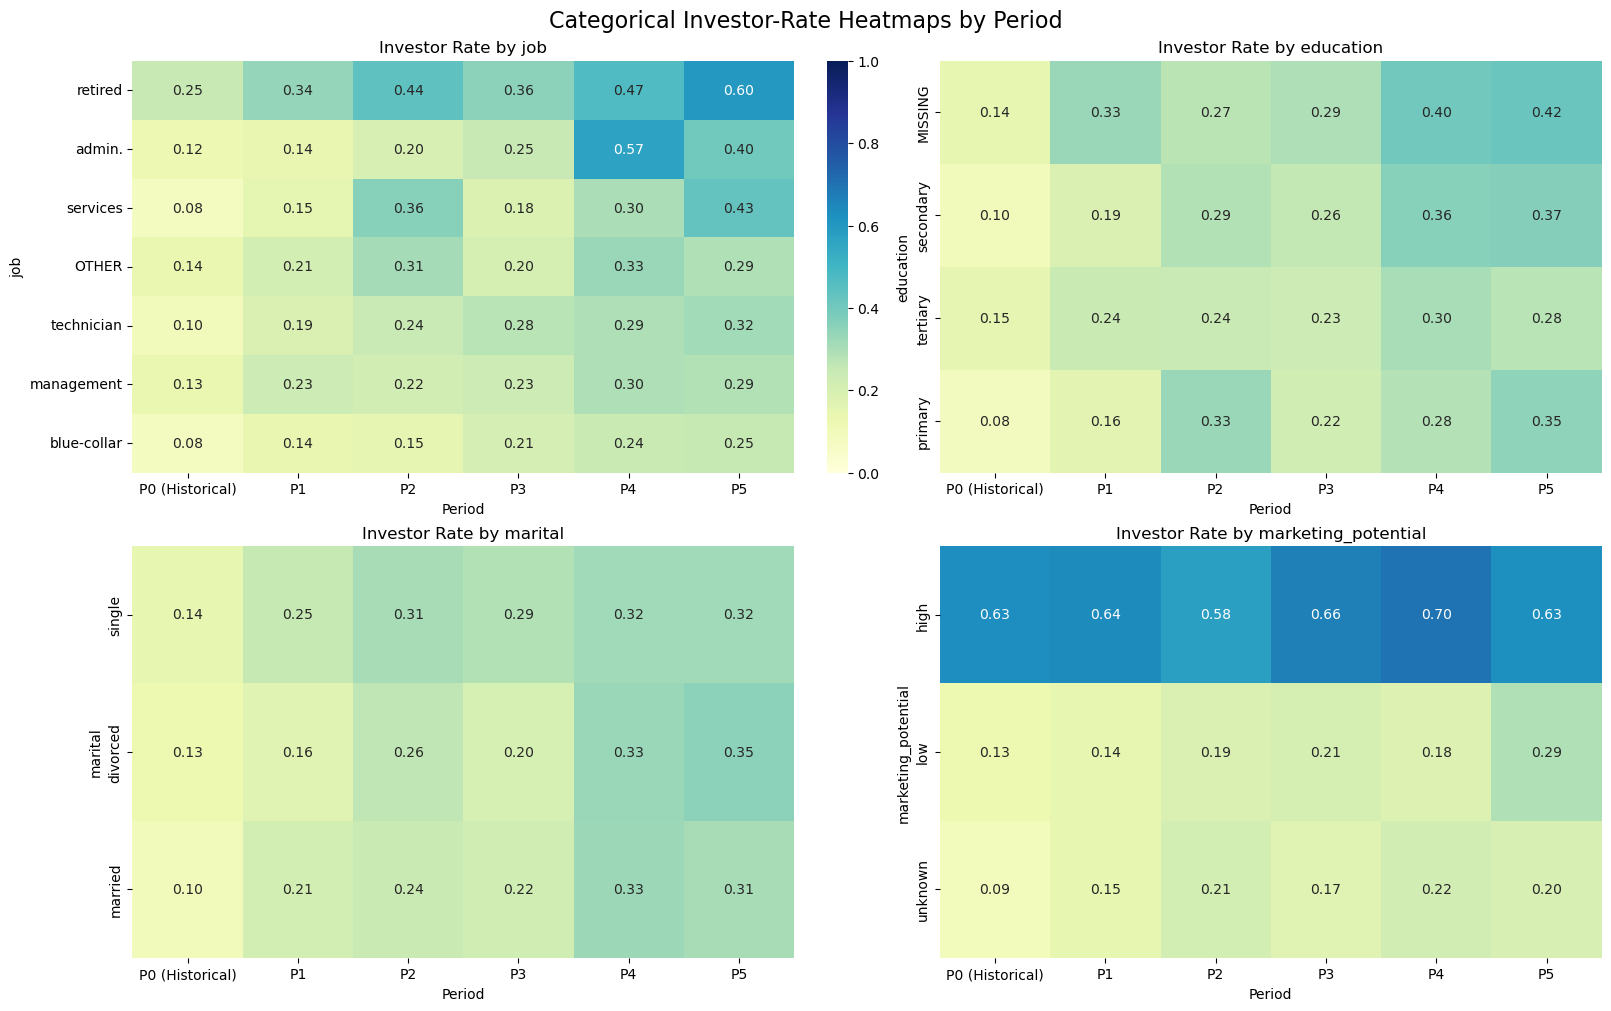

{'figures': [<Figure size 1600x1000 with 4 Axes>,
  <Figure size 1600x1000 with 4 Axes>,
  <Figure size 1600x1000 with 5 Axes>],
 'summary':    Period Key           Period  Clients  Investors  Non-Investors  \
 0           0  P0 (Historical)     7700        884           6816   
 1           1               P1     1200        253            947   
 2           2               P2     1101        293            808   
 3           3               P3     1084        261            823   
 4           4               P4      856        277            579   
 5           5               P5      824        259            565   
 
    Investor Rate  Avg Investment (Investors)  Median Investment (Investors)  \
 0       0.114805                  481.786968                         333.91   
 1       0.210833                  869.854269                         556.83   
 2       0.266122                  672.845188                         492.31   
 3       0.240775                  831.581724   

In [178]:
df_results_5 = pd.read_csv('results-2026-03-19.csv')

df_period5 = df_data_predict.merge(df_results_5, on="id", how="inner", validate="one_to_one")
df_period5["y"] = (df_period5["investment"] > 0).astype(int)

df_all_including5 = pd.concat([df_hist, df_period1, df_period2, df_period3, df_period4, df_period5], ignore_index=True) #just for analysis

weekly_investment_dashboard(df_all_including5)